# Bank Marketing Campaign — Term Deposit Subscription Prediction

**Project type:** Binary Classification
**Dataset:** UCI Bank Marketing (`bank-full.csv`, 45,211 rows × 17 columns)
**Target:** `y` — whether the client subscribed to a term deposit (`yes` / `no`)

This notebook documents the full machine learning workflow for the project, from business
understanding through to a tuned, threshold-optimized model ready for production deployment.

**Pipeline overview:**

| Sprint | Stage | Description |
|---|---|---|
| 1 | Business & Data Understanding | Problem framing, data inspection, cleaning, EDA, outlier handling |
| 2 | Preprocessing & Baseline | Pipeline-based feature scaling/encoding, train/test split, baseline model |
| 3 | Model Comparison | Multiple algorithms, overfitting/underfitting diagnostics |
| 4 | Optimization | Feature importance, feature selection, class imbalance handling |
| 5 | Tuning & Finalization | Hyperparameter tuning, threshold optimization, final model selection |
| 6 | MLOps  | MLflow experiment tracking + Prefect orchestration |


---
# Sprint 1 : Business Understanding & Data Understanding
---

## 1. Business Problem Statement

A Portuguese banking institution runs **outbound telemarketing campaigns** to sell **term
deposit** products to its existing customers. Each campaign involves bank representatives
calling clients — sometimes multiple times — to persuade them to subscribe.

These campaigns are **expensive and inefficient**: representatives spend time calling clients
who are unlikely to subscribe, which wastes operational hours and call-center budget, and can
also hurt customer experience through repeated, irrelevant contact.

**Business objective:** Use historical campaign data (client demographics, financial attributes,
and previous campaign interactions) to **predict which clients are likely to subscribe** to a
term deposit. This allows the bank to:

- Prioritize outreach toward high-probability customers
- Reduce the number of unproductive calls
- Improve conversion rate and campaign ROI
- Personalize campaign strategy per customer segment


## 2. What is the Challenge?

This is framed as a **binary classification problem**: predict `y ∈ {yes, no}` for each client.

The key modeling challenges are:

1. **Severe class imbalance** — only ~11.7% of clients subscribe (`yes`), so a naive model can
   score "well" on accuracy while almost never identifying actual subscribers.
2. **Highly skewed numerical features** — `balance` and `duration` have heavy right-skew (and
   `balance` even contains negative values), which can distort distance-based and linear models
   if left untransformed.
3. **Mixed feature types** — a combination of binary, ordinal, and nominal categorical features
   alongside numeric ones, each needing a different encoding strategy.
4. **Business-aligned metric choice** — accuracy is not a useful metric here. The bank cares more
   about **recall** (catching as many true subscribers as possible) balanced against
   **precision** (not wasting calls on false positives), making **F1-score, ROC-AUC, and a
   tuned decision threshold** more appropriate success metrics than raw accuracy.
5. **Generalization** — preventing overfitting on the high-capacity boosting models while
   avoiding underfitting on simpler linear baselines.


## 3. Data Collection & Loading

The dataset is provided as a semicolon-separated CSV file (`bank-full.csv`, saved locally as
`train.csv`). We load it with pandas.


In [1]:
import pandas as pd

DATA_PATH = "../data/train.csv"

df = pd.read_csv(DATA_PATH, sep=";")

print(f"Number of rows    : {df.shape[0]}")
print(f"Number of columns : {df.shape[1]}")


Number of rows    : 45211
Number of columns : 17


## 4. Data Inspection

We start with a structural look at the data: column types, sample rows, and summary statistics.


In [2]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [3]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
45206,51,technician,married,tertiary,no,825,no,no,cellular,17,nov,977,3,-1,0,unknown,yes
45207,71,retired,divorced,primary,no,1729,no,no,cellular,17,nov,456,2,-1,0,unknown,yes
45208,72,retired,married,secondary,no,5715,no,no,cellular,17,nov,1127,5,184,3,success,yes
45209,57,blue-collar,married,secondary,no,668,no,no,telephone,17,nov,508,4,-1,0,unknown,no
45210,37,entrepreneur,married,secondary,no,2971,no,no,cellular,17,nov,361,2,188,11,other,no


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB


**Expected schema (17 columns):**

| Column | Type | Description |
|---|---|---|
| `age` | int | Client's age |
| `job` | object | Type of job |
| `marital` | object | Marital status |
| `education` | object | Education level |
| `default` | object | Has credit in default? |
| `balance` | int | Average yearly account balance (€) |
| `housing` | object | Has a housing loan? |
| `loan` | object | Has a personal loan? |
| `contact` | object | Contact communication type |
| `day` | int | Last contact day of the month |
| `month` | object | Last contact month of year |
| `duration` | int | Last contact duration (seconds) |
| `campaign` | int | Number of contacts in this campaign |
| `pdays` | int | Days since last contact in a previous campaign (-1 = never contacted) |
| `previous` | int | Number of contacts before this campaign |
| `poutcome` | object | Outcome of the previous campaign |
| `y` | object | **Target** — subscribed to a term deposit? |


In [5]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [6]:
# Split columns into numerical and categorical groups for easier downstream analysis
num_col = df.select_dtypes(include=["int64", "float64"]).columns
cat_col = df.select_dtypes(include=["object"]).columns

print("Numerical columns   :", list(num_col))
print("Categorical columns :", list(cat_col))


Numerical columns   : ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
Categorical columns : ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome', 'y']


### Insight — Data Inspection

- The dataset has **45,211 rows and 17 columns**, with **7 numerical** and **10 categorical**
  (object-typed) columns.
- `df.describe()` already flags two issues to investigate further: `balance` has a **negative
  minimum** (clients can be overdrawn), and `pdays` uses **-1 as a sentinel value** for "never
  contacted before" rather than a true numeric distance — this needs to be handled carefully
  rather than treated as a literal number of days.
- No missing values are visible from `df.info()` (all columns show 45,211 non-null), which we
  verify explicitly in the next step.


## 5. Data Cleaning

We check for missing values, duplicate rows, and then standardize column names so that the
features are self-descriptive for everyone working with this notebook downstream.


In [7]:
# Missing values
df.isnull().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

In [8]:
# Duplicate rows
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 0


In [9]:
# Unique values per categorical column — useful to spot typos, unexpected categories,
# or "unknown" placeholders that need special handling later
for col in cat_col:
    print(f"{col:12s}: {df[col].unique()}")


job         : ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
marital     : ['married' 'single' 'divorced']
education   : ['tertiary' 'secondary' 'unknown' 'primary']
default     : ['no' 'yes']
housing     : ['yes' 'no']
loan        : ['no' 'yes']
contact     : ['unknown' 'cellular' 'telephone']
month       : ['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']
poutcome    : ['unknown' 'failure' 'other' 'success']
y           : ['no' 'yes']


In [2]:
# Standardize column names to be more descriptive and self-explanatory
df.rename(columns={
    "y": "target",
    "default": "default_credit",
    "housing": "housing_loan",
    "loan": "personal_loan",
    "contact": "contact_type",
    "poutcome": "previous_outcome",
    "pdays": "no_time_contacted_days_before",
    "duration": "last_call_duration",
    "campaign": "contacts_in_campaign",
    "previous": "contacted_in_before_campaing",
}, inplace=True)

# Recompute column groups after renaming
num_col = df.select_dtypes(include=["int64", "float64"]).columns
cat_col = df.select_dtypes(include=["object"]).columns

print("Numerical columns   :", list(num_col))
print("Categorical columns :", list(cat_col))


Numerical columns   : ['age', 'balance', 'day', 'last_call_duration', 'contacts_in_campaign', 'no_time_contacted_days_before', 'contacted_in_before_campaing']
Categorical columns : ['job', 'marital', 'education', 'default_credit', 'housing_loan', 'personal_loan', 'contact_type', 'month', 'previous_outcome', 'target']


In [11]:
df.head()

,age,job,marital,education,default_credit,balance,housing_loan,personal_loan,contact_type,day,month,last_call_duration,contacts_in_campaign,no_time_contacted_days_before,contacted_in_before_campaing,previous_outcome,target
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


### Insight — Data Cleaning

- **No missing values** and **no duplicate rows** were found — the dataset is already clean
  at the row level, so no imputation or de-duplication is required.
- Several categorical columns (`education`, `job`, `contact_type`, `previous_outcome`) contain
  an explicit `"unknown"` category. This is **not a missing value** in the technical sense (no
  NaNs), but it is a genuine "we don't know" signal that we preserve as its own category rather
  than imputing, since dropping or guessing it could discard useful information.
- Column names have been renamed to be self-descriptive (e.g. `y` → `target`,
  `pdays` → `no_time_contacted_days_before`) to make the rest of the notebook easier to read.


## 6. Exploratory Data Analysis (EDA)

We explore the data in three stages:

1. **Univariate analysis** — distribution of each feature on its own
2. **Bivariate analysis** — relationship of each feature with the target
3. **Multivariate analysis** — relationships among multiple features together (correlation structure)


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


### 6.1 Univariate Analysis

#### Numerical columns


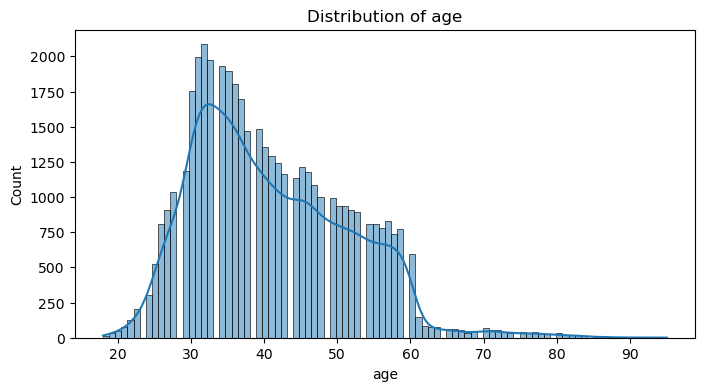

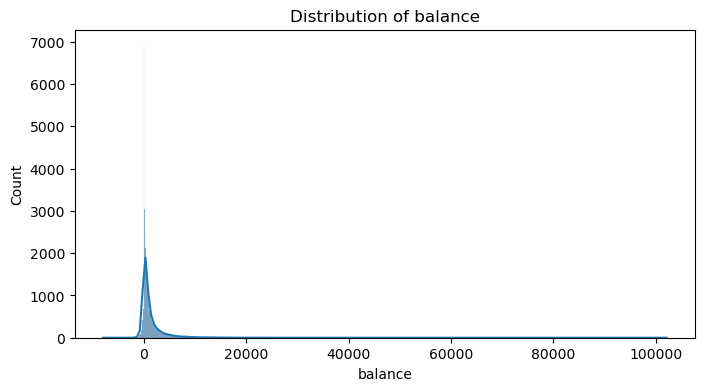

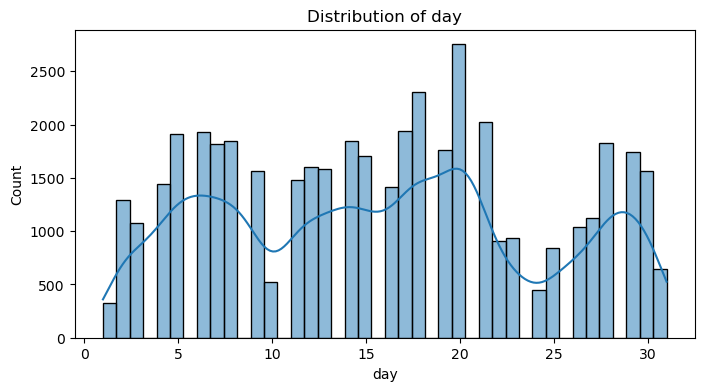

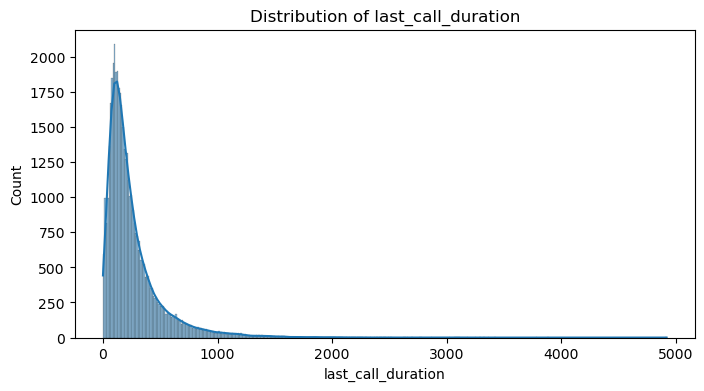

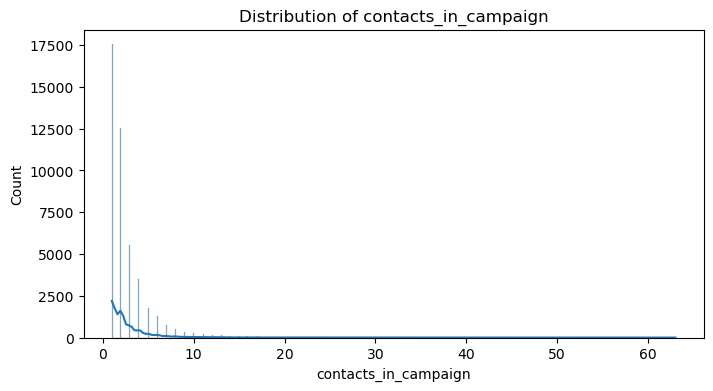

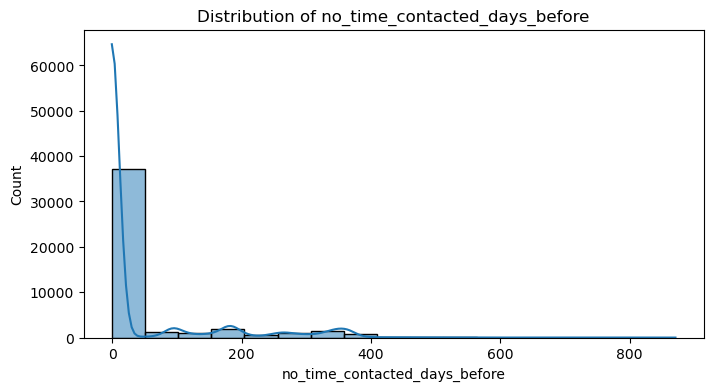

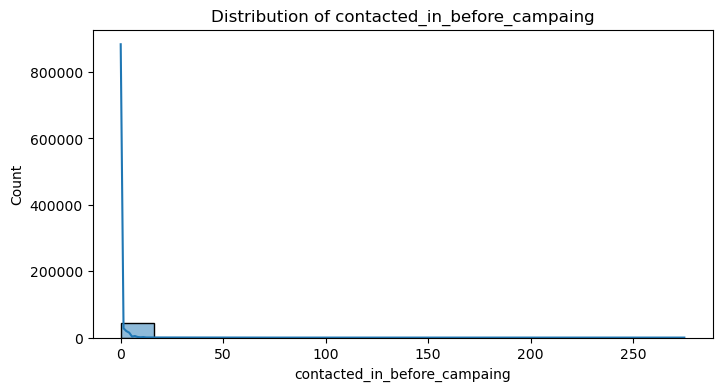

In [13]:
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()


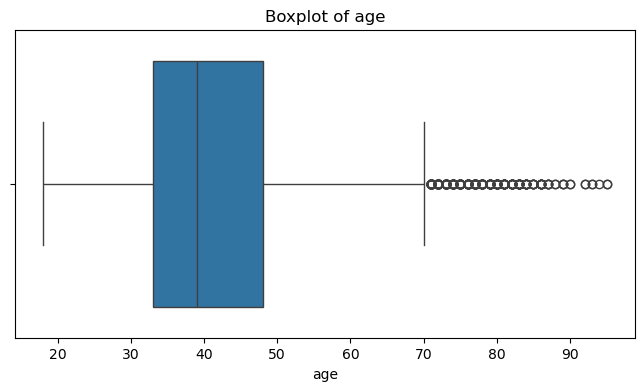

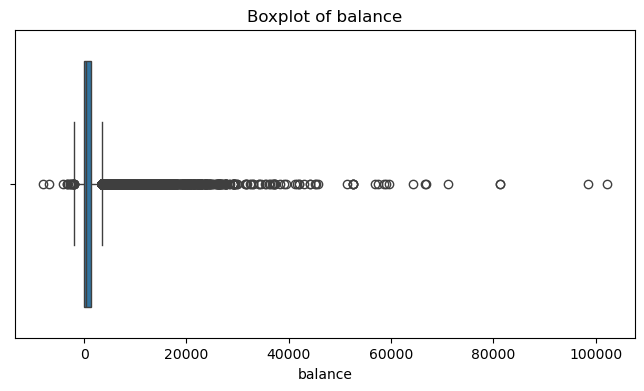

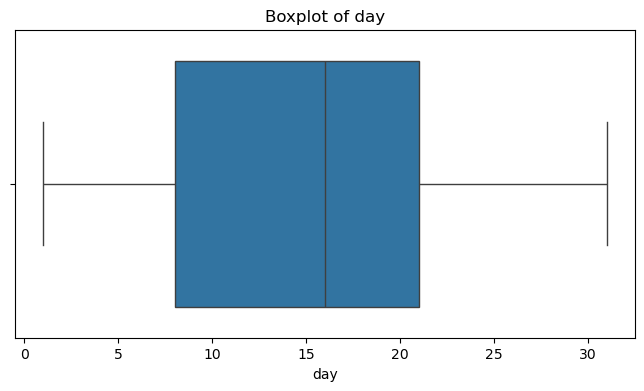

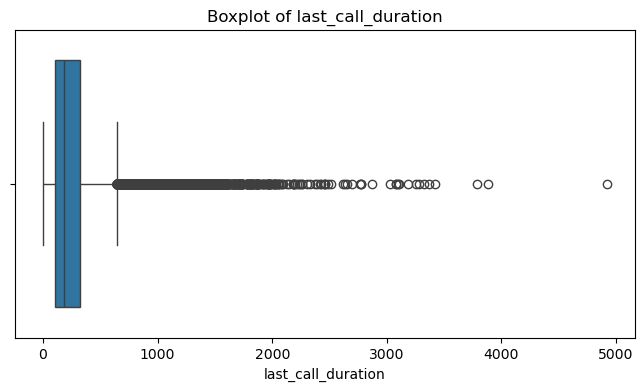

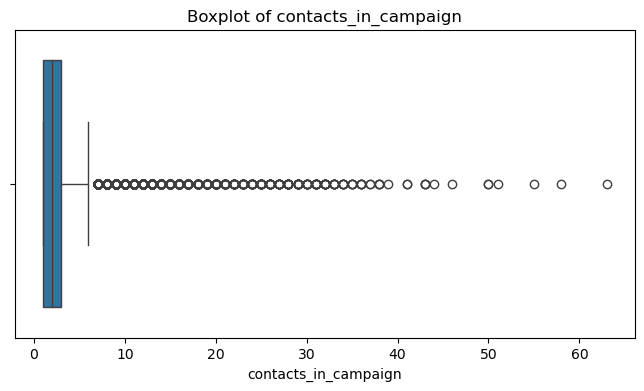

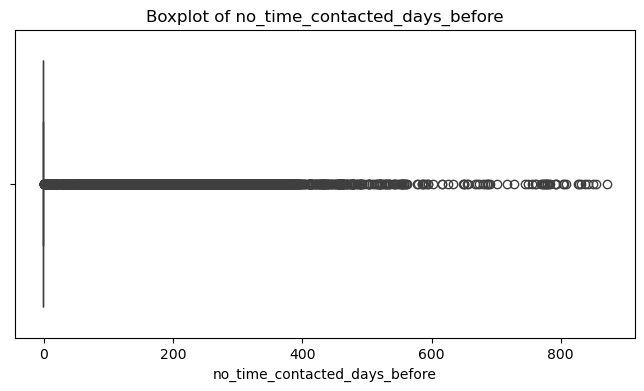

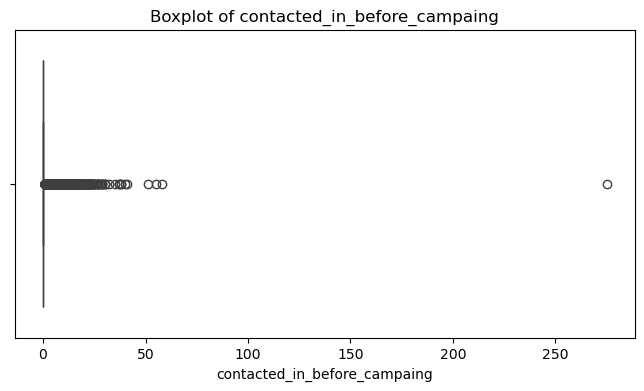

In [14]:
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()


In [15]:
for col in num_col:
    print(f"Skewness of {col:32s}: {df[col].skew():.4f}")


Skewness of age                             : 0.6848
Skewness of balance                         : 8.3603
Skewness of day                             : 0.0931
Skewness of last_call_duration              : 3.1443
Skewness of contacts_in_campaign            : 4.8987
Skewness of no_time_contacted_days_before   : 2.6157
Skewness of contacted_in_before_campaing    : 41.8465


#### Categorical columns


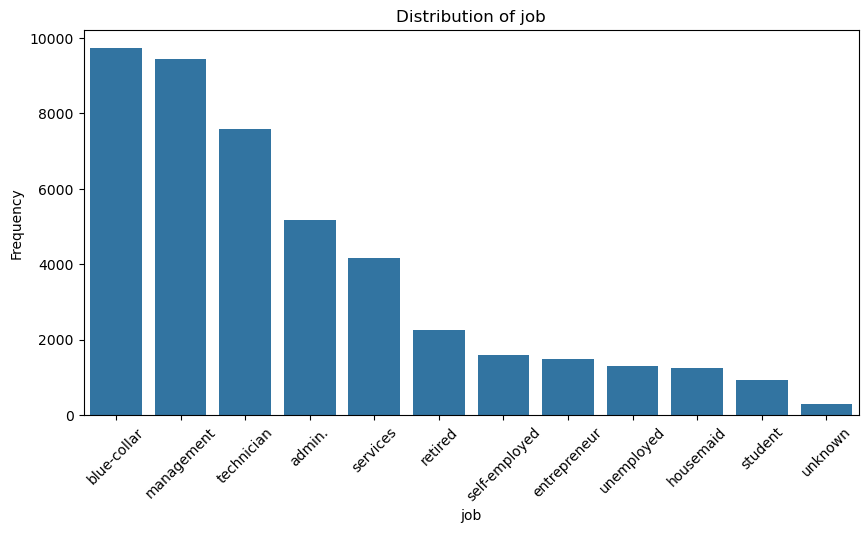

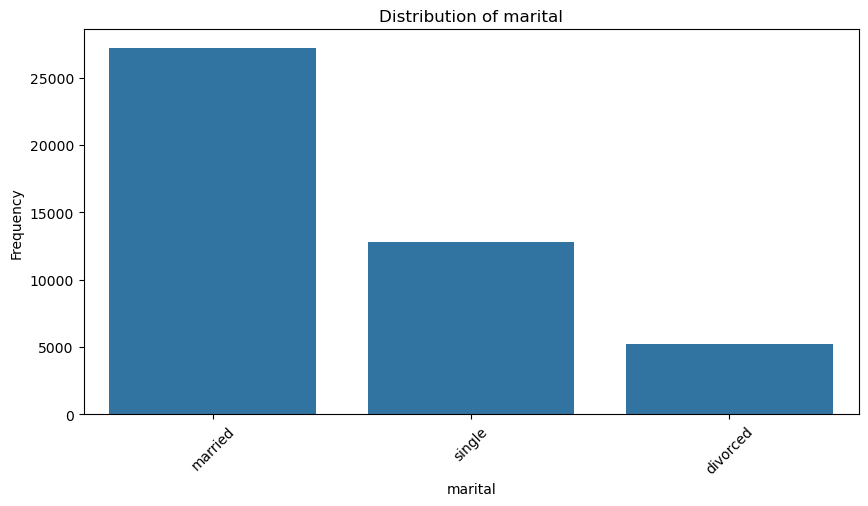

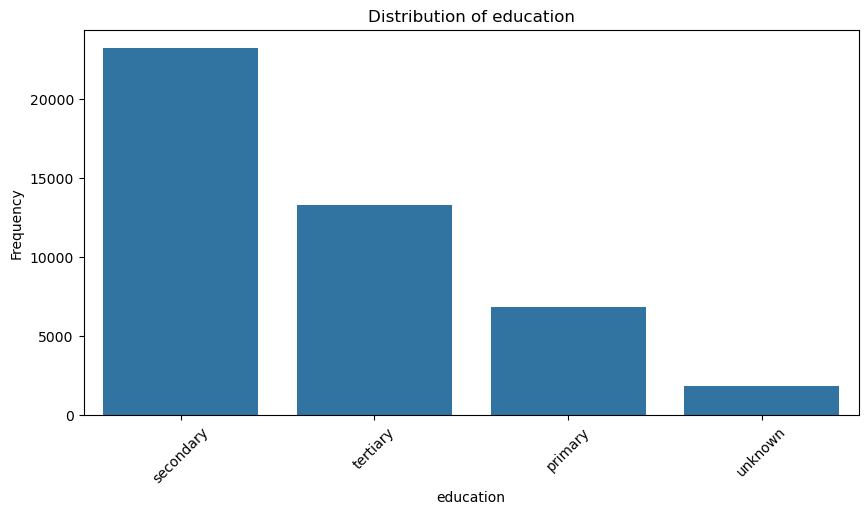

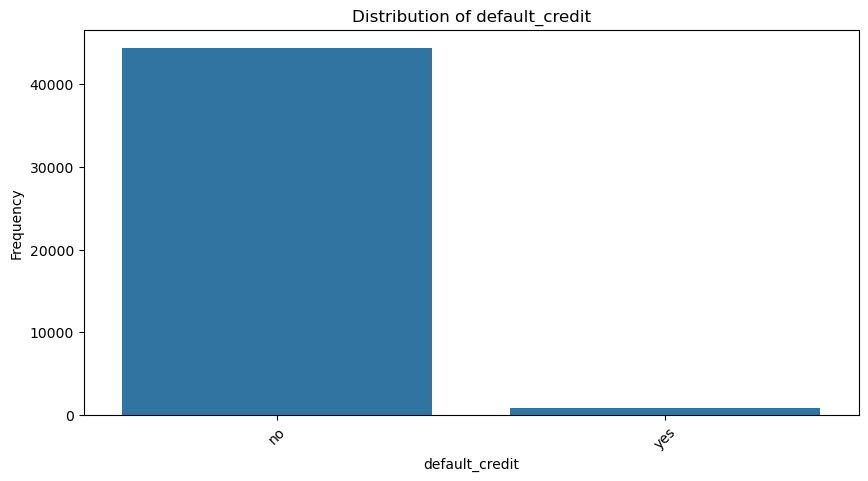

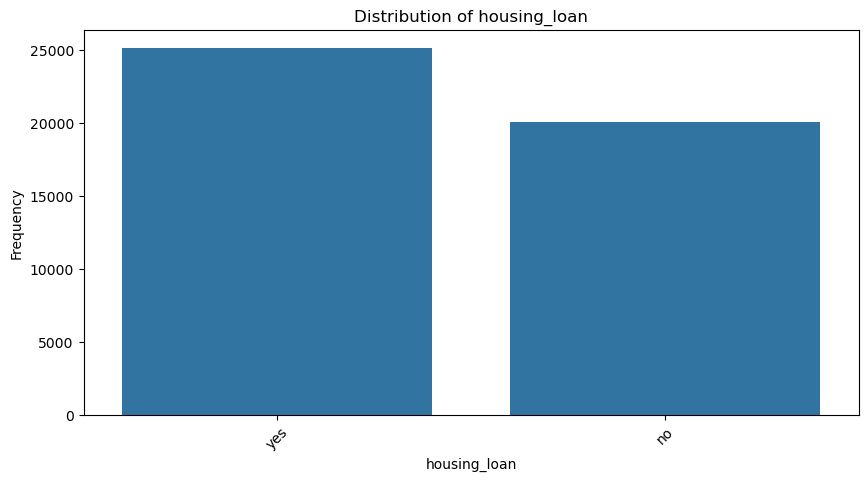

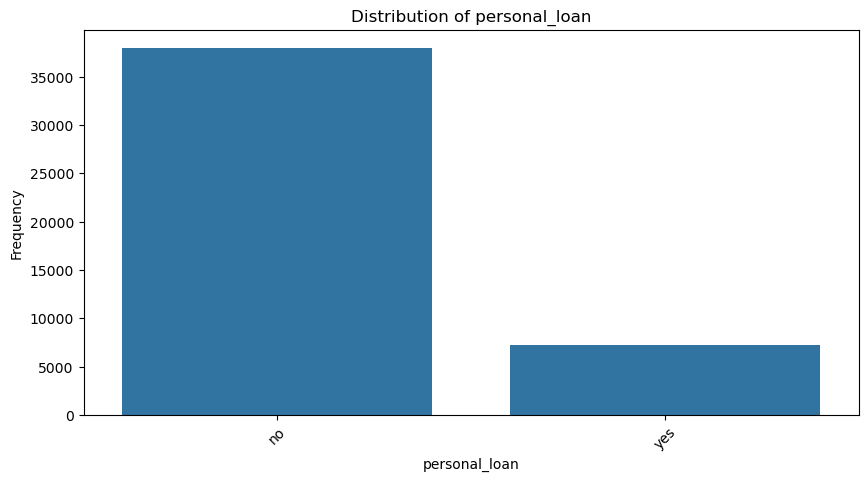

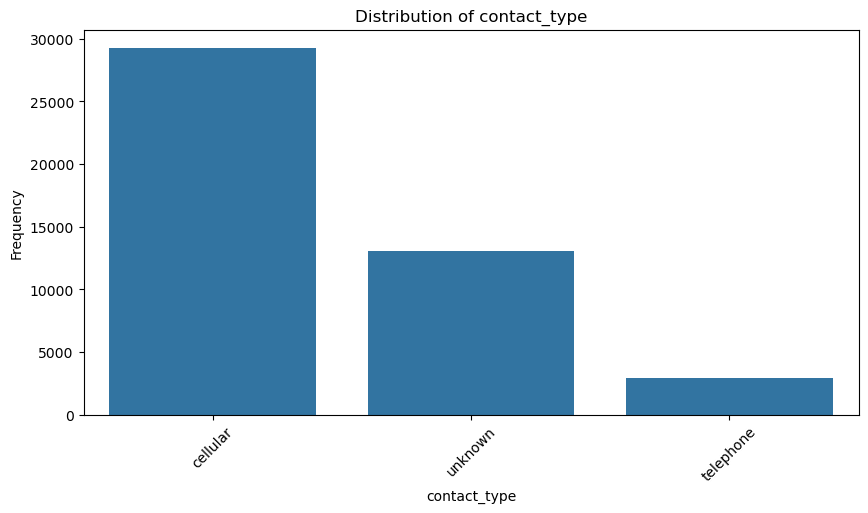

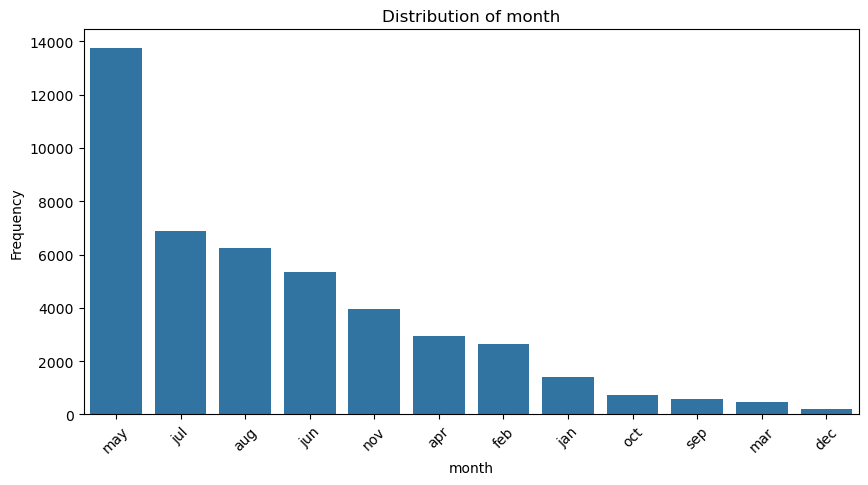

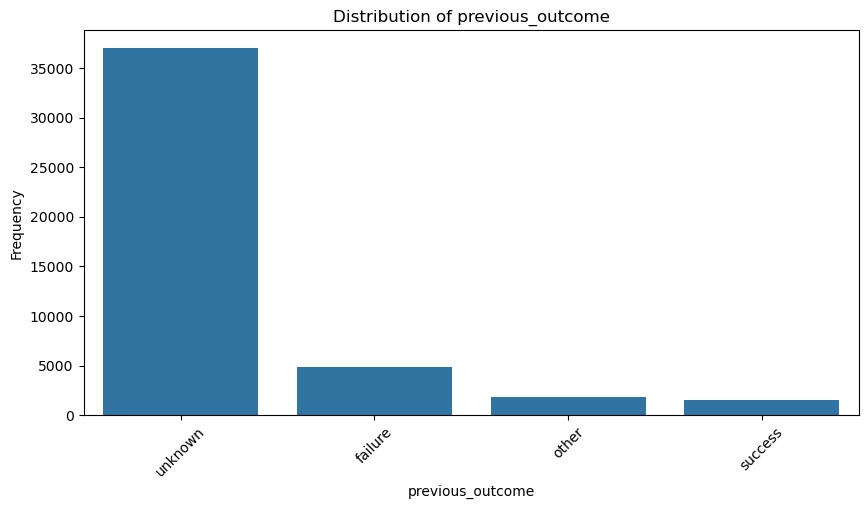

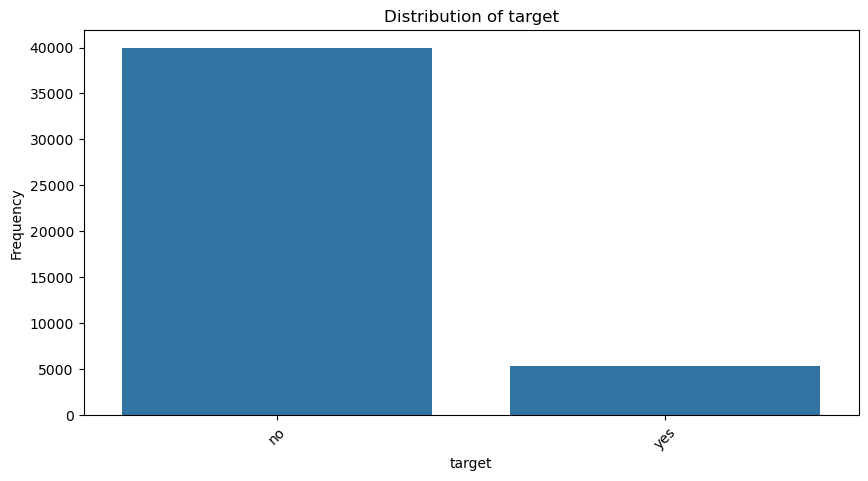

In [16]:
for col in cat_col:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation=45)
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()


### 📌 Insight — Univariate Analysis

- The dataset has **7 numerical** and **10 categorical** columns.
- Several numerical features are **heavily right-skewed**:
  `balance` (skew ≈ 8.4), `last_call_duration` (skew ≈ 3.1), `contacts_in_campaign` (skew ≈ 4.9),
  and especially `contacted_in_before_campaing` (skew ≈ 41.8) — a small number of clients with
  very high values are pulling the distribution's tail far to the right.
- `age` is mildly right-skewed (skew ≈ 0.68) and `day` is nearly symmetric (skew ≈ 0.09) — these
  do not need transformation.
- Most clients fall in the **30–50 age range**, are in **management/blue-collar/technician**
  jobs, are **married**, and were contacted via **cellular** in **May**.
- `previous_outcome` is dominated by `"unknown"` — most clients had no prior campaign history.


### 6.2 Bivariate Analysis

Relationship of each feature against the **target** variable.


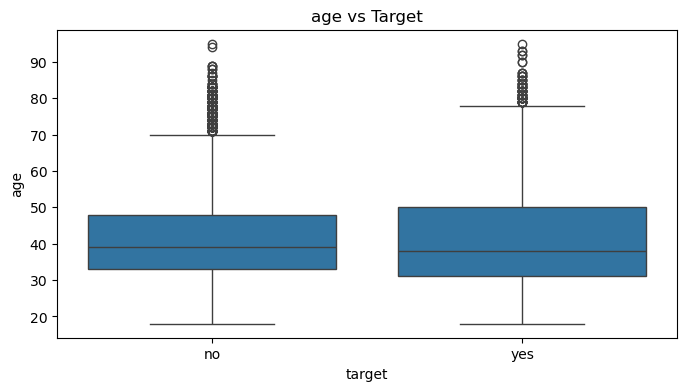

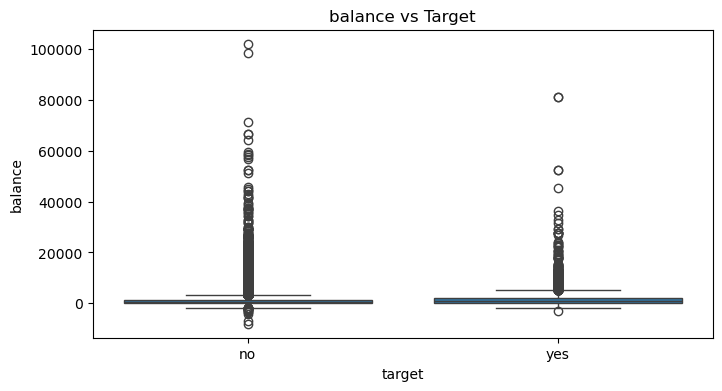

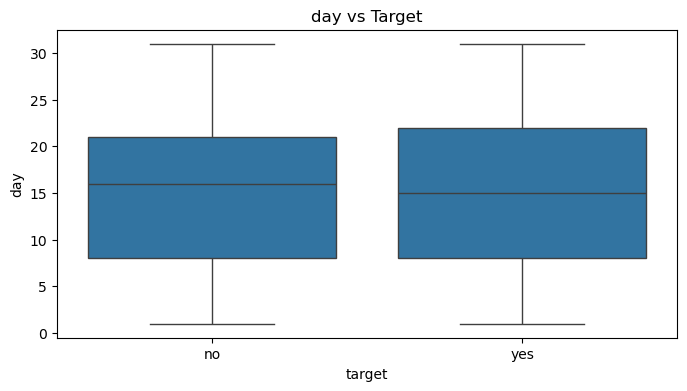

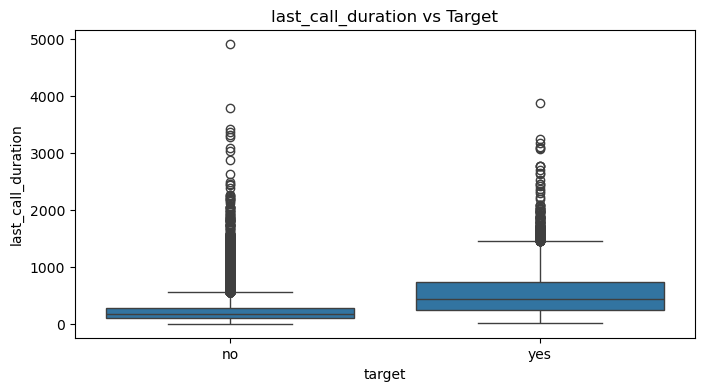

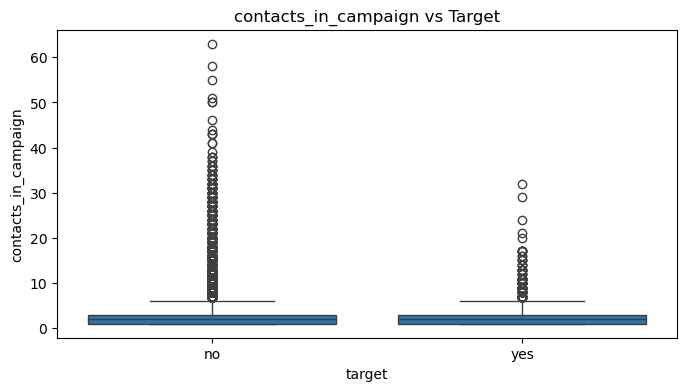

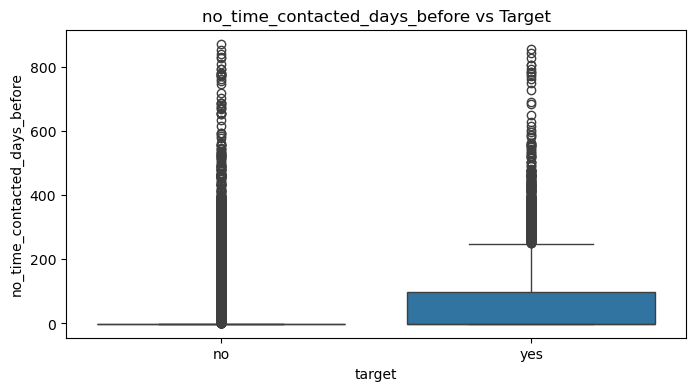

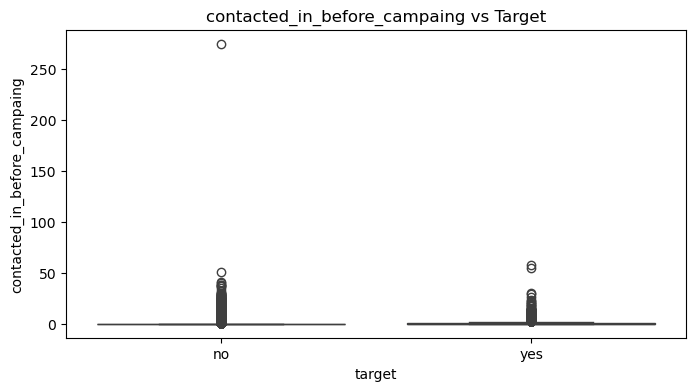

In [17]:
for col in num_col:
    plt.figure(figsize=(8, 4))
    sns.boxplot(x="target", y=col, data=df)
    plt.title(f"{col} vs Target")
    plt.show()


In [18]:
for col in num_col:
    print(df.groupby("target")[col].mean())
    print("-" * 40)


target
no     40.838986
yes    41.670070
Name: age, dtype: float64
----------------------------------------
target
no     1303.714969
yes    1804.267915
Name: balance, dtype: float64
----------------------------------------
target
no     15.892290
yes    15.158253
Name: day, dtype: float64
----------------------------------------
target
no     221.182806
yes    537.294574
Name: last_call_duration, dtype: float64
----------------------------------------
target
no     2.846350
yes    2.141047
Name: contacts_in_campaign, dtype: float64
----------------------------------------
target
no     36.421372
yes    68.702968
Name: no_time_contacted_days_before, dtype: float64
----------------------------------------
target
no     0.502154
yes    1.170354
Name: contacted_in_before_campaing, dtype: float64
----------------------------------------


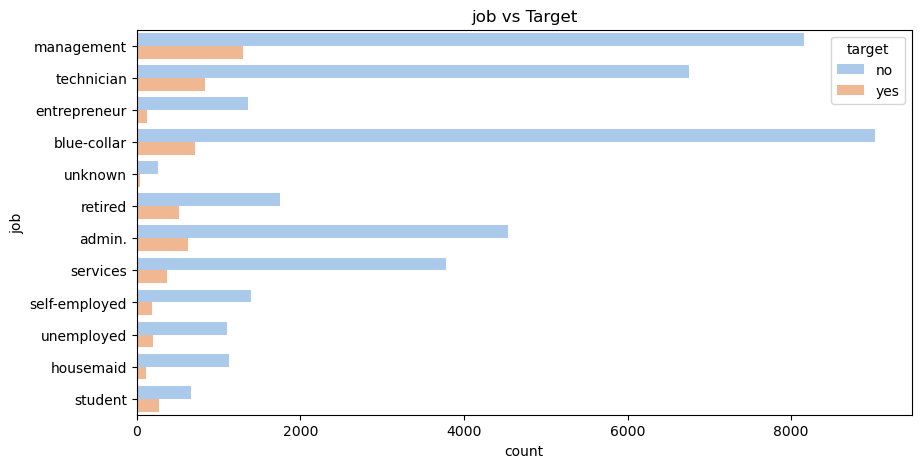

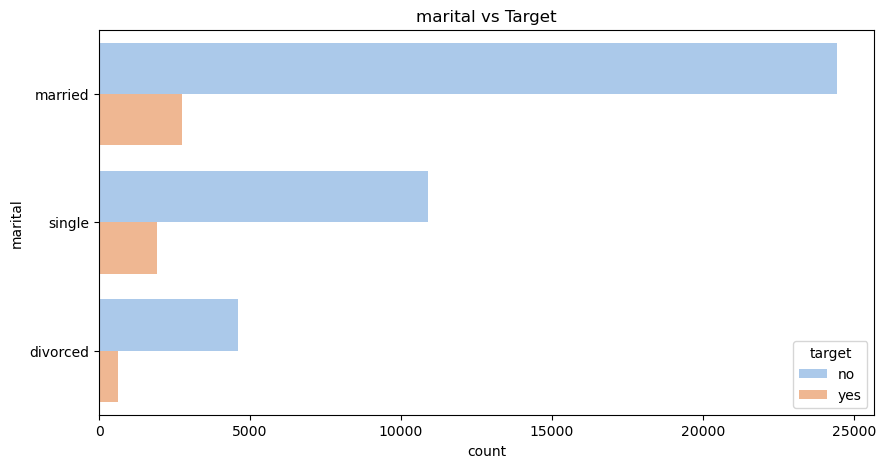

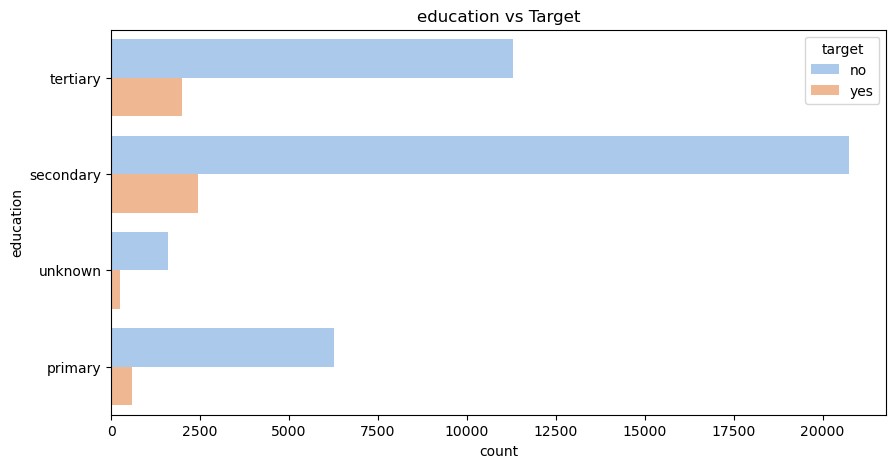

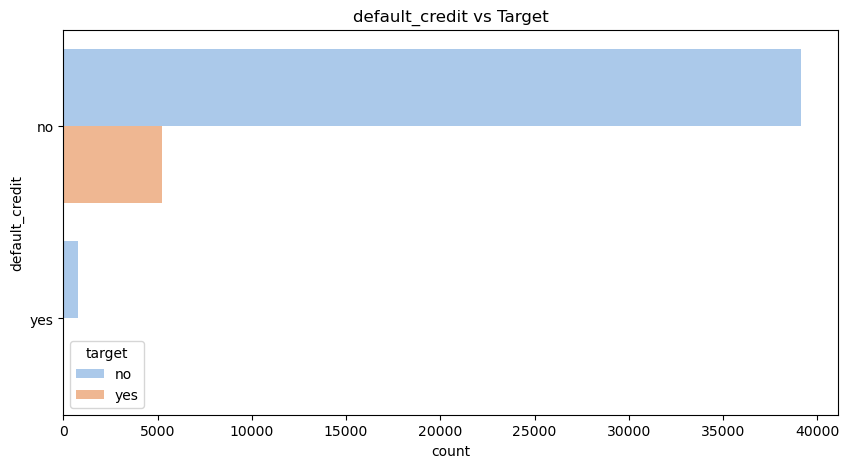

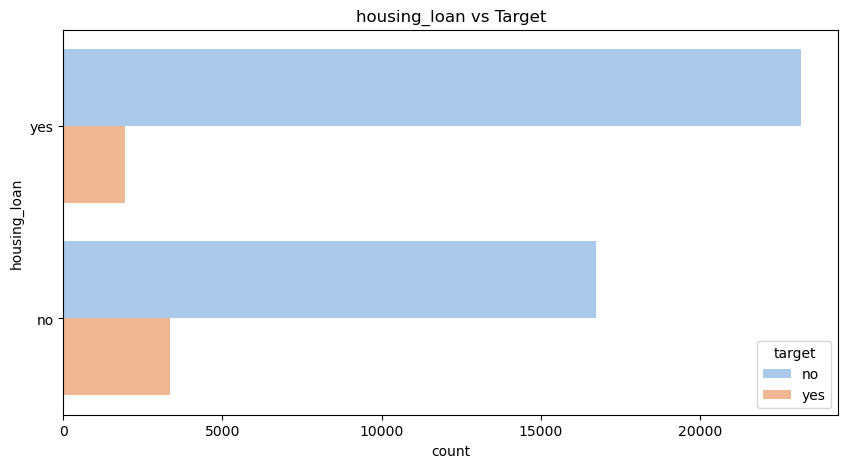

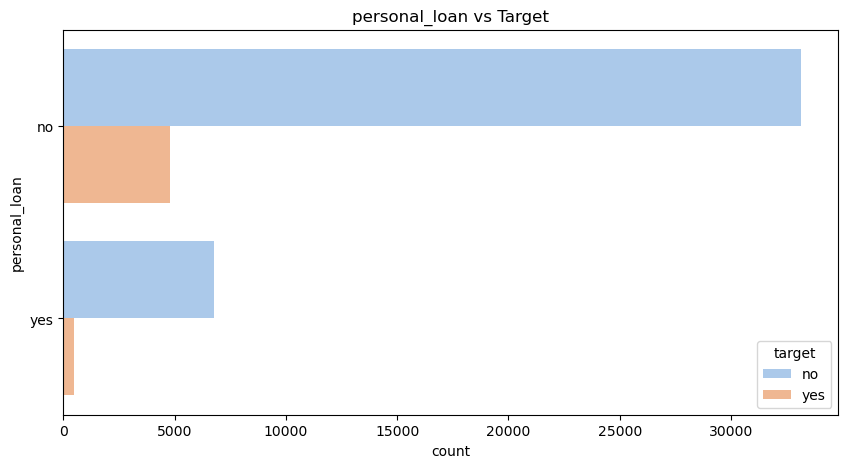

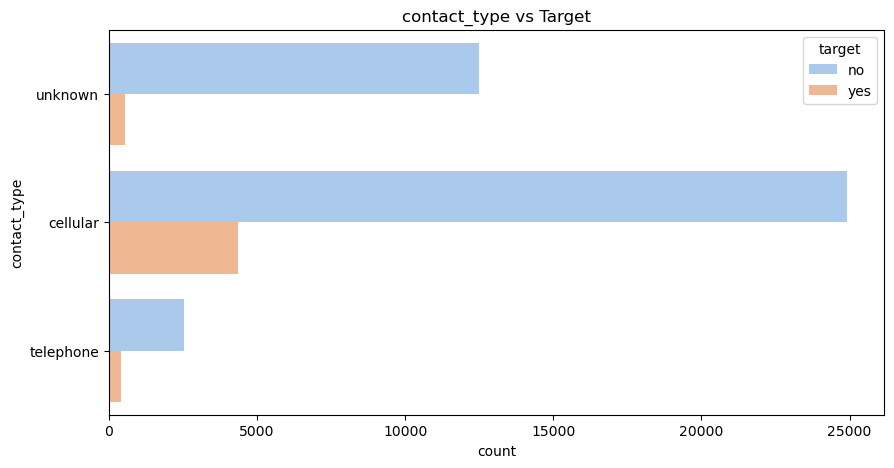

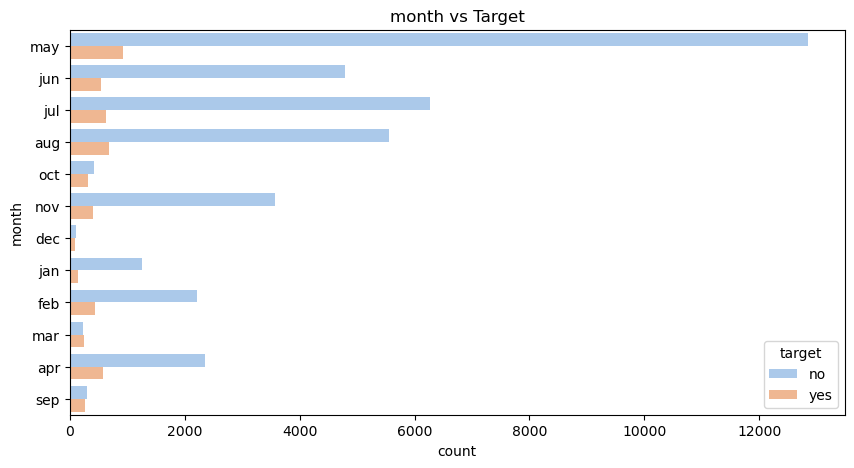

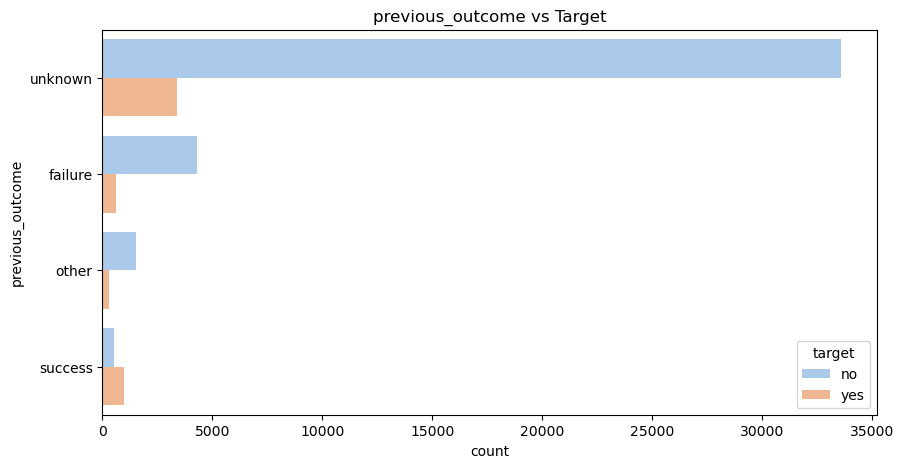

In [19]:
for col in cat_col:
    if col == "target":
        continue
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, y=col, hue="target", palette="pastel")
    plt.title(f"{col} vs Target")
    plt.show()


In [20]:
for col in cat_col:
    if col == "target":
        continue
    print(pd.crosstab(df[col], df["target"], normalize="index"))
    print("=" * 50)


target               no       yes
job                              
admin.         0.877973  0.122027
blue-collar    0.927250  0.072750
entrepreneur   0.917283  0.082717
housemaid      0.912097  0.087903
management     0.862444  0.137556
retired        0.772085  0.227915
self-employed  0.881571  0.118429
services       0.911170  0.088830
student        0.713220  0.286780
technician     0.889430  0.110570
unemployed     0.844973  0.155027
unknown        0.881944  0.118056
target          no       yes
marital                     
divorced  0.880545  0.119455
married   0.898765  0.101235
single    0.850508  0.149492
target           no       yes
education                    
primary    0.913735  0.086265
secondary  0.894406  0.105594
tertiary   0.849936  0.150064
unknown    0.864297  0.135703
target                no       yes
default_credit                    
no              0.882039  0.117961
yes             0.936196  0.063804
target              no       yes
housing_loan              

### 📌 Insight — Bivariate Analysis

- **`last_call_duration`** shows the clearest separation between classes — clients who eventually
  subscribed tend to have had noticeably longer last calls.
- **Job**: `student` (~28.7%) and `retired` (~22.8%) clients subscribe at much higher rates than
  `blue-collar` (~7.3%) or `services` (~8.9%) clients.
- **Education**: subscription rate rises with education level — `tertiary` (~15.0%) outperforms
  `primary` (~8.6%).
- **Loans**: clients **without** a housing loan (~16.7%) or personal loan (~12.7%) subscribe more
  often than those **with** one (~7.7% and ~6.7% respectively) — existing debt obligations appear
  to reduce appetite for a new deposit product.
- **Contact type**: `cellular` and `telephone` contacts convert far better (~14.9% / ~13.4%) than
  `unknown` contact methods (~4.1%).
- **Month** is highly informative: `mar`, `sep`, `oct`, and `dec` have dramatically higher
  conversion (40–52%) than `may` (~6.7%), even though May has the most call volume — this is a
  strong candidate signal for future campaign-timing decisions.
- **Previous outcome**: clients whose previous campaign ended in `"success"` convert at **~64.7%**
  this time — by far the strongest single predictor we've observed, which matches the feature
  importance results later in this notebook.


### 6.3 Multivariate Analysis

Correlation structure across multiple numerical features simultaneously.


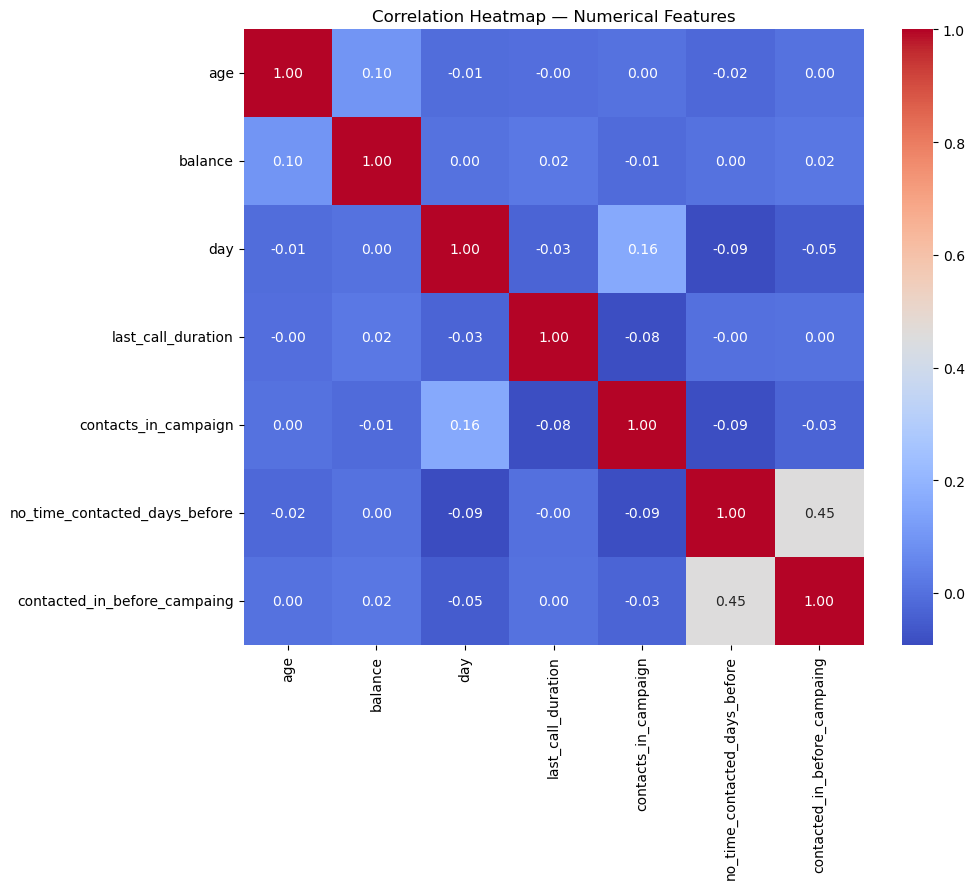

In [21]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[num_col].corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap — Numerical Features")
plt.show()


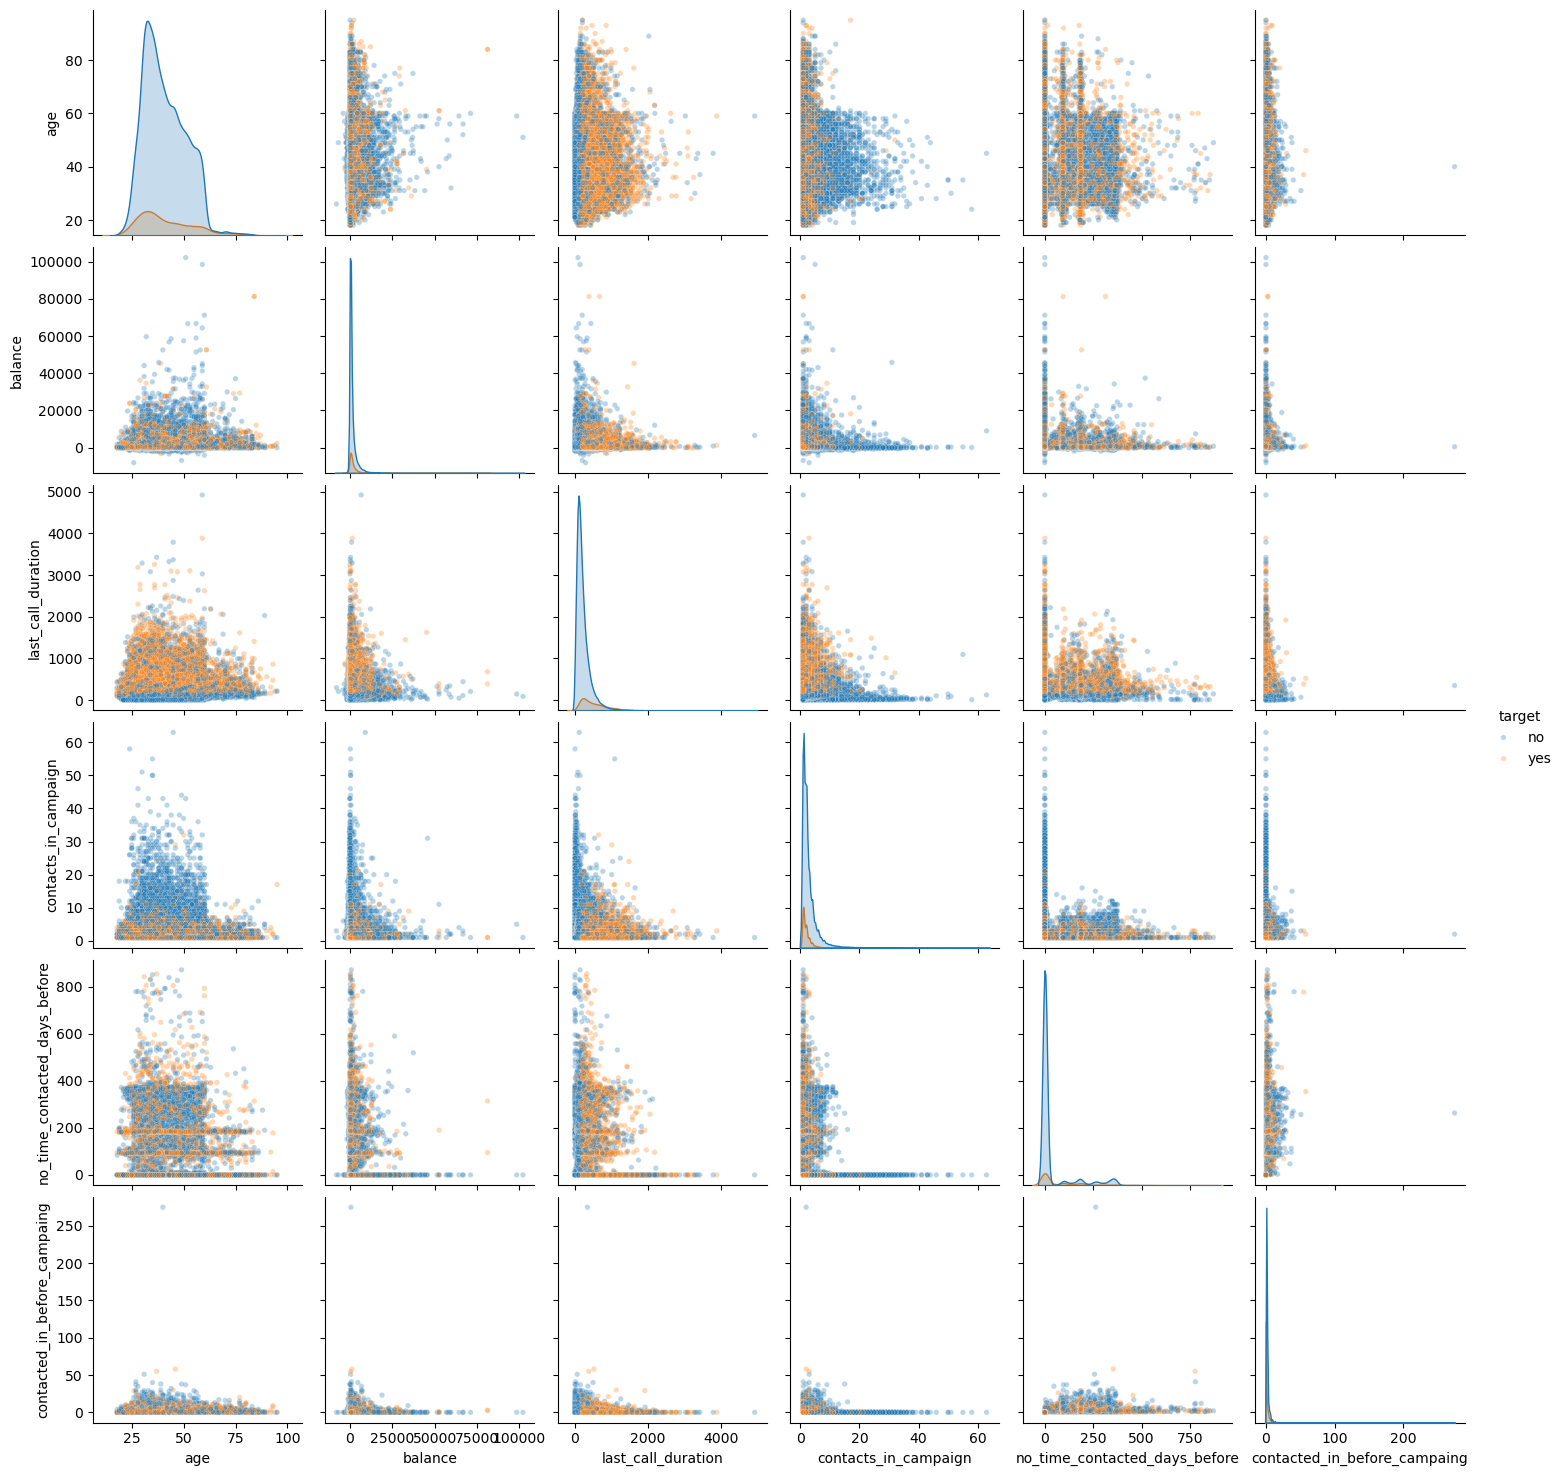

In [22]:
# Pairwise relationships among the numerical features, colored by target,
# to look for multi-feature interaction patterns that a single bivariate plot would miss
selected_num = df[num_col].drop(columns=["day"])  # day is just a calendar artifact, not informative alone

sns.pairplot(
    df,
    vars=list(selected_num.columns),
    hue="target",
    plot_kws={"alpha": 0.3, "s": 15},
)
plt.show()


### 📌 Insight — Multivariate Analysis

- The numerical features show **very weak pairwise linear correlation** with each other
  (most off-diagonal values are close to 0), which means **multicollinearity is not a major
  concern** for linear models here — we don't need to drop numeric features purely on
  correlation grounds.
- `contacted_in_before_campaing` (previous) and `no_time_contacted_days_before` (pdays) show a
  mild positive relationship, which makes sense — clients contacted more times before naturally
  have a recorded "days since last contact" value rather than the `-1` sentinel.
- No single pair of numerical features fully separates the classes on its own — this hints that
  the target is driven more by **categorical context** (previous outcome, contact type, month)
  and **call duration**, rather than purely by numeric financial attributes — consistent with
  what we found in the bivariate analysis above.


## 7. Outlier & Skew Treatment

From the univariate analysis, `balance` and `last_call_duration` are the most heavily skewed
numerical features. Rather than removing outliers (which would discard real customers), we
apply a **log transform** to compress the long right tail and make these features better
behaved for the linear baseline model.

> Note: `balance` can be negative (minimum ≈ -8019), so a plain `log()` is not defined for it.
> We shift the values to be non-negative before applying `log1p`.


In [5]:
# balance can be negative, so shift by its minimum before applying log1p
df["balance_log"] = np.log1p(df["balance"] - df["balance"].min() + 1)
df["duration_log"] = np.log1p(df["last_call_duration"])

print("Skewness before vs after log transform")
print(f"  balance              : {df['balance'].skew():.4f}  ->  balance_log   : {df['balance_log'].skew():.4f}")
print(f"  last_call_duration    : {df['last_call_duration'].skew():.4f}  ->  duration_log  : {df['duration_log'].skew():.4f}")


Skewness before vs after log transform
  balance              : 8.3603  ->  balance_log   : 1.4669
  last_call_duration    : 3.1443  ->  duration_log  : -0.4542


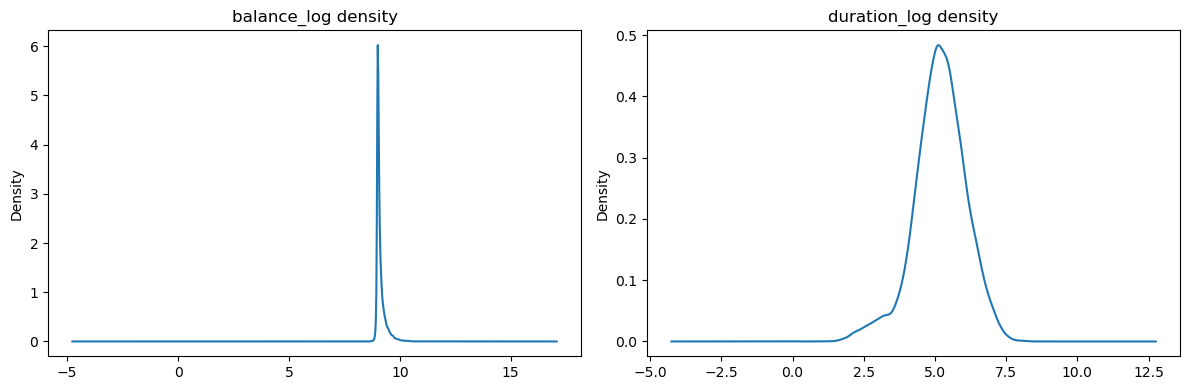

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
df["balance_log"].plot(kind="density", ax=axes[0], title="balance_log density")
df["duration_log"].plot(kind="density", ax=axes[1], title="duration_log density")
plt.tight_layout()
plt.show()


### 📌 Insight — Outlier / Skew Treatment

- The log transform reduces `balance` skew from **~8.4 → ~1.5** and `last_call_duration` skew
  from **~3.1 → ~-0.45** — both now sit much closer to a normal-ish shape.
- We deliberately **do not** transform `contacts_in_campaign`, `contacted_in_before_campaing`,
  or `no_time_contacted_days_before`. These columns are dominated by a single common value
  (e.g. most clients have `previous = 0` or `pdays = -1`), so a log transform would not meaningfully
  improve their distribution — tree-based models handle this kind of sparsity natively, and we
  will scale them with a standard scaler for the linear baseline instead of transforming them.


---
# Sprint 2 : Preprocessing Pipeline, Train/Test Split & Baseline Model
---

## 8. Feature Scaling & Encoding — Pipeline Formation

Rather than hand-encoding columns inline in the notebook (which is hard to reuse and easy to get
out of sync with production code), we build the preprocessing as a proper **scikit-learn
`Pipeline` + `ColumnTransformer`**, defined in `preprocessing.py` / `custom_transformer.py`.
This is the **same pipeline used in `train.py` and `predict.py`**, so the notebook, training
script, and inference script all share one source of truth for preprocessing logic.

**Pipeline structure:**

| Column group | Columns | Transformation |
|---|---|---|
| `num_cols` | `age`, `campaign`, `previous` | `StandardScaler` |
| `log_cols` | `balance`, `duration` | `log1p` transform → `StandardScaler` |
| `binary_cols` | `housing`, `loan` | `OneHotEncoder(drop="if_binary")` |
| `ordinal_cols` | `education` | `OrdinalEncoder` (unknown < primary < secondary < tertiary) |
| `nominal_cols` | `job`, `marital`, `contact`, `poutcome` | `OneHotEncoder(drop="first")` |

After the `ColumnTransformer`, a custom `FeatureSelector` step renames the transformed columns
to human-readable names and keeps only the subset of features identified as useful during
feature selection (Sprint 3).

> ⚠️ **Bug fix applied to `custom_transformer.py`:** the original `FeatureSelector.fit()` returned
> `self` without setting any learned attribute. On current scikit-learn (≥1.4), this causes
> `Pipeline.transform()` to raise `NotFittedError` even right after a successful `fit_transform()`,
> because scikit-learn's `check_is_fitted()` looks for an attribute ending in `_` to confirm the
> step was actually fit. This silently breaks calling `.transform()` on new data (e.g. in
> `predict.py`) separately from `.fit_transform()` on training data. The fix sets
> `self.n_features_in_` inside `fit()`, following the standard scikit-learn convention.


In [6]:
# preprocessing_pipeline is defined in preprocessing.py, which wires together the
# ColumnTransformer above with the FeatureSelector from custom_transformer.py
import sys
import os

# Add src/ to Python's import search path (notebooks/ and src/ are siblings)
sys.path.append(os.path.abspath(os.path.join("..", "src")))

from preprocessing import preprocessing_pipeline

preprocessing_pipeline


,steps,"[('preprocessor', ...), ('feature_selector', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('log_num', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 9. Train / Test Split

We split **before** fitting any preprocessing step, so that no information from the test set
leaks into the scaler/encoder statistics (a common and easy-to-miss source of data leakage).


In [7]:
from sklearn.model_selection import train_test_split

# Use the ORIGINAL raw column names (pre-rename) since preprocessing_pipeline expects
# the raw UCI schema — this keeps the pipeline reusable directly in train.py / predict.py
RAW_DATA_PATH = "../data/train.csv"
raw_df = pd.read_csv(RAW_DATA_PATH, sep=";")

X = raw_df.drop(columns=["y"])
y = raw_df["y"].map({"yes": 1, "no": 0})

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y,   # preserve the ~88/12 class balance in both splits
)

print(f"X_train: {X_train.shape}   X_test: {X_test.shape}")
print(f"y_train positive rate: {y_train.mean():.4f}   y_test positive rate: {y_test.mean():.4f}")


X_train: (36168, 16)   X_test: (9043, 16)
y_train positive rate: 0.1170   y_test positive rate: 0.1170


In [8]:
# Fit the preprocessing pipeline on the training data ONLY, then transform both splits.
# fit_transform learns scaler means/std + encoder categories from X_train;
# transform (no fit) reuses those same learned statistics on X_test.
X_train_processed = preprocessing_pipeline.fit_transform(X_train)
X_test_processed = preprocessing_pipeline.transform(X_test)

print("Processed feature columns:", list(X_train_processed.columns))
print("Processed shapes -> train:", X_train_processed.shape, " test:", X_test_processed.shape)

X_train_processed.head()


Processed feature columns: ['age', 'education', 'housing_loan', 'personal_loan', 'contacts_in_campaign', 'contacted_in_before_campaing', 'balance_log', 'duration_log', 'job_blue-collar', 'job_student', 'marital_married', 'marital_single', 'previous_outcome_other', 'previous_outcome_success', 'previous_outcome_unknown', 'contact_type_telephone', 'contact_type_unknown']
Processed shapes -> train: (36168, 17)  test: (9043, 17)


,age,education,housing_loan,personal_loan,contacts_in_campaign,contacted_in_before_campaing,balance_log,duration_log,job_blue-collar,job_student,marital_married,marital_single,previous_outcome_other,previous_outcome_success,previous_outcome_unknown,contact_type_telephone,contact_type_unknown
0,-0.460434,2.0,0.0,0.0,-0.246104,-0.241509,-0.127042,-0.241798,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
1,-1.589641,2.0,0.0,0.0,0.398202,2.664584,1.338886,1.776444,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
2,0.292371,2.0,1.0,0.0,0.398202,-0.241509,-0.464179,2.478738,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0.668773,2.0,0.0,0.0,2.653271,-0.241509,-0.604502,-1.721212,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,-0.272233,2.0,0.0,0.0,2.331118,-0.241509,-0.456820,-1.204404,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0


### 📌 Insight — Preprocessing & Split

- The pipeline outputs **17 model-ready features** with clean, human-readable names
  (`balance_log`, `housing_loan`, `previous_outcome_success`, etc.) instead of the raw
  `ColumnTransformer` output names like `num__age`.
- Because the scaler and encoders are **fit only on `X_train`**, the test set transformation
  uses statistics learned exclusively from training data — this avoids data leakage and gives
  an honest estimate of generalization performance.
- The same `preprocessing_pipeline` object is reused unchanged in `train.py`, so any
  improvement made here (e.g. adding a new encoded feature) automatically propagates to the
  production training script.


## 10. Baseline Model

We start with **Logistic Regression** as a simple, interpretable baseline. Every later model
must beat this baseline to justify the added complexity.


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, log_loss

baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train_processed, y_train)

train_pred = baseline_model.predict(X_train_processed)
test_pred = baseline_model.predict(X_test_processed)


#### Validation on Train Data

In [17]:
print(confusion_matrix(y_train, train_pred))
print(classification_report(y_train, train_pred))


[[31178   759]
 [ 2856  1375]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95     31937
           1       0.64      0.32      0.43      4231

    accuracy                           0.90     36168
   macro avg       0.78      0.65      0.69     36168
weighted avg       0.88      0.90      0.89     36168



#### Validation on Test Data

In [18]:
print(confusion_matrix(y_test, test_pred))
print(classification_report(y_test, test_pred))


[[7805  180]
 [ 710  348]]
              precision    recall  f1-score   support

           0       0.92      0.98      0.95      7985
           1       0.66      0.33      0.44      1058

    accuracy                           0.90      9043
   macro avg       0.79      0.65      0.69      9043
weighted avg       0.89      0.90      0.89      9043



In [19]:
train_loss = log_loss(y_train, baseline_model.predict_proba(X_train_processed))
test_loss = log_loss(y_test, baseline_model.predict_proba(X_test_processed))

print(f"Train log loss: {train_loss:.4f}")
print(f"Test log loss : {test_loss:.4f}")


Train log loss: 0.2400
Test log loss : 0.2420


### 📌 Insight — Baseline Model

- The baseline reaches **~90% accuracy on both train and test sets** — but this number is
  misleading given the ~88/12 class imbalance; a model that always predicted "no" would already
  score ~88% accuracy.
- The more informative numbers are **recall (~0.32) and precision (~0.64) for the positive
  class** — the baseline only catches about a third of actual subscribers.
- Train and test metrics are very close to each other (log loss ≈ 0.30 vs ≈ 0.30), so the
  baseline is **not overfitting** — if anything it may be underfitting the positive class due to
  its linear decision boundary and the class imbalance.
- This sets the bar: any model we try next should aim to **improve recall and F1** without
  sacrificing the model's ability to generalize (train ≈ test performance).


## 11. Training Multiple Models

We now train a range of algorithms — spanning linear, distance-based, probabilistic, and
ensemble approaches — to see which family of models suits this problem best before investing
further effort into tuning.


In [20]:
# Algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
)

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(random_state=42, eval_metric="logloss"),
    "SVM": SVC(probability=True, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": BernoulliNB(),
}


## 12. Model Evaluation — Overfit / Underfit Diagnostics & Comparison Table

For each model we compute training and test metrics together, then flag the fit quality using a
simple rule: a large train–test accuracy gap signals **overfitting**, low accuracy on both signals
**underfitting**, and anything else is treated as a **good fit**.


In [31]:
def evaluate_models(models, X_train, X_test, y_train, y_test):
    '''Fits each model and returns a comparison DataFrame with overfit/underfit diagnostics.'''
    results = []

    for name, model in models.items():
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_accuracy = accuracy_score(y_train, train_pred)
        test_accuracy = accuracy_score(y_test, test_pred)
        precision = precision_score(y_test, test_pred)
        recall = recall_score(y_test, test_pred)
        f1 = f1_score(y_test, test_pred)

        # ROC-AUC & log loss require predicted probabilities (not all models expose this)
        if hasattr(model, "predict_proba"):
            test_prob = model.predict_proba(X_test)[:, 1]
            roc_auc = roc_auc_score(y_test, test_prob)
            test_logloss = log_loss(y_test, test_prob)
        else:
            roc_auc, test_logloss = None, None

        # Overfit / underfit diagnostic
        gap = train_accuracy - test_accuracy
        if train_accuracy < 0.75 and test_accuracy < 0.75:
            status = "Underfitting"
        elif gap > 0.10:
            status = "Overfitting"
        else:
            status = "Good Fit"

        results.append({
            "Model": name,
            "Train Accuracy": round(train_accuracy, 4),
            "Test Accuracy": round(test_accuracy, 4),
            "Accuracy Gap": round(gap, 4),
            "Precision": round(precision, 4),
            "Recall": round(recall, 4),
            "F1 Score": round(f1, 4),
            "ROC AUC": round(roc_auc, 4) if roc_auc is not None else None,
            "Log Loss": round(test_logloss, 4) if test_logloss is not None else None,
            "Status": status,
        })

    return pd.DataFrame(results)


results_df = evaluate_models(models, X_train_processed, X_test_processed, y_train, y_test)


### 📊 Comparison Table — All Models

In [36]:
results_df.sort_values(by=["Recall", "ROC AUC"], ascending=False).reset_index(drop=True)

,Model,Train Accuracy,Test Accuracy,Accuracy Gap,Precision,Recall,F1 Score,ROC AUC,Log Loss,Status
0,XGBoost,0.9343,0.9014,0.0329,0.6210,0.4026,0.4885,0.8953,0.2400,Good Fit
1,Gradient Boosting,0.9064,0.9032,0.0032,0.6423,0.3904,0.4856,0.9029,0.2307,Good Fit
2,Logistic Regression,0.9000,0.9016,-0.0015,0.6591,0.3289,0.4388,0.8903,0.2420,Good Fit
3,Naive Bayes,0.8751,0.8745,0.0006,0.4502,0.3289,0.3801,0.8122,0.3185,Good Fit
4,KNN,0.9205,0.8899,0.0306,0.5515,0.3138,0.4000,0.8054,1.1834,Good Fit
5,SVM,0.8997,0.8962,0.0036,0.6735,0.2183,0.3298,0.8484,0.2908,Good Fit


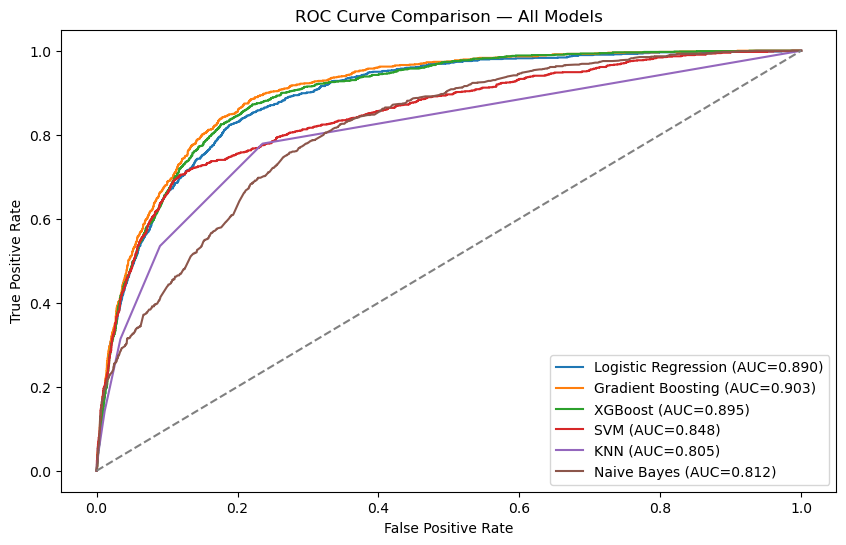

In [37]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 6))

for name, model in models.items():
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X_test_processed)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, probs)
        auc = roc_auc_score(y_test, probs)
        plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", color="grey")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison — All Models")
plt.legend()
plt.show()


### 📌 Insight — Model Comparison

- All six models land in the **"Good Fit"** zone — none show a train/test accuracy gap large
  enough to call overfitting, and all clear the 75% underfitting threshold.
- **Gradient Boosting and XGBoost** lead on Recall (~0.38–0.39) and ROC-AUC (~0.90), making
  them the strongest candidates among the baseline algorithms.
- **SVM** has the highest precision (~0.67) but the lowest recall (~0.22) — it's the most
  conservative model, missing many true subscribers in exchange for being confident about the
  ones it does flag.
- **KNN** has a relatively high log loss (~1.17), suggesting its predicted probabilities are
  poorly calibrated even though its accuracy looks fine — a useful reminder that accuracy alone
  hides important differences between models.
- **Naive Bayes** is the weakest performer across nearly every metric, likely because its
  conditional-independence assumption doesn't hold well for this feature set.

**Models carried forward for further optimization: Gradient Boosting, XGBoost.** We also trial
**LightGBM** next, since it offers similar boosting performance to XGBoost at lower computational
cost — a meaningful consideration as this pipeline scales toward production retraining.


---
# Sprint 3 : Model Optimization
---

## 13. LightGBM Trial

Before committing to a final shortlist, we also trial **LightGBM** — a gradient boosting
implementation that is typically faster to train than scikit-learn's `GradientBoostingClassifier`
or XGBoost on tabular data of this size, which matters once this pipeline is retrained regularly
in production.


In [21]:
from lightgbm import LGBMClassifier

lgb_model = LGBMClassifier(random_state=42)
lgb_model.fit(X_train_processed, y_train)

lgb_test_pred = lgb_model.predict(X_test_processed)
lgb_train_pred = lgb_model.predict(X_train_processed)

print("Test Recall :", recall_score(y_test, lgb_test_pred))
print("Train Recall:", recall_score(y_train, lgb_train_pred))


[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.010538 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327
Test Recall : 0.389413988657845
Train Recall: 0.47293783975419523


### 📌 Insight — Algorithm Shortlist

Gradient Boosting and XGBoost deliver similar performance but are noticeably heavier to train.
LightGBM matches them closely while training faster, which becomes important once
hyperparameter search and periodic retraining are introduced.

**Models carried forward for the rest of this notebook:**
1. Gradient Boosting (`GradientBoostingClassifier`)
2. XGBoost (`XGBClassifier`)
3. LightGBM (`LGBMClassifier`)


## 14. Feature Importance Analysis

Before simplifying the model, we ask: **which features are actually driving its decisions?**

Note: `preprocessing_pipeline` already includes a `FeatureSelector` step that keeps only a
pre-chosen subset of 17 features (see `custom_transformer.py`). To analyze importance
**before** that selection is applied — and confirm the selection still makes sense — we
temporarily rebuild the underlying `ColumnTransformer` **without** the `FeatureSelector` step,
giving us the full 26-feature encoded set to rank.


In [22]:
from sklearn.compose import ColumnTransformer
from preprocessing import (
    num_pipeline, log_pipeline, binary_pipeline, ordinal_pipeline, nominal_pipeline,
    num_cols, log_cols, binary_cols, ordinal_cols, nominal_cols,
)

# Same structure as preprocessing_pipeline, but WITHOUT the FeatureSelector step,
# so we can inspect importances across the full encoded feature space first.
full_preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("log_num", log_pipeline, log_cols),
    ("binary", binary_pipeline, binary_cols),
    ("ordinal", ordinal_pipeline, ordinal_cols),
    ("nominal", nominal_pipeline, nominal_cols),
])

X_train_full = full_preprocessor.fit_transform(X_train)
X_test_full = full_preprocessor.transform(X_test)

full_feature_names = full_preprocessor.get_feature_names_out()
X_train_full = pd.DataFrame(X_train_full, columns=full_feature_names, index=X_train.index)
X_test_full = pd.DataFrame(X_test_full, columns=full_feature_names, index=X_test.index)

print("Full encoded feature set:", list(X_train_full.columns))
print("Shape:", X_train_full.shape)


Full encoded feature set: ['num__age', 'num__campaign', 'num__previous', 'log_num__balance', 'log_num__duration', 'binary__housing_yes', 'binary__loan_yes', 'ordinal__education', 'nominal__job_blue-collar', 'nominal__job_entrepreneur', 'nominal__job_housemaid', 'nominal__job_management', 'nominal__job_retired', 'nominal__job_self-employed', 'nominal__job_services', 'nominal__job_student', 'nominal__job_technician', 'nominal__job_unemployed', 'nominal__job_unknown', 'nominal__marital_married', 'nominal__marital_single', 'nominal__contact_telephone', 'nominal__contact_unknown', 'nominal__poutcome_other', 'nominal__poutcome_success', 'nominal__poutcome_unknown']
Shape: (36168, 26)


In [23]:
# Fit fresh copies of the boosting models on the FULL (unselected) feature set
# purely to rank feature importance — these are separate from the `models` dict
# trained earlier on the FeatureSelector-reduced output.
gb_full = GradientBoostingClassifier(random_state=42).fit(X_train_full, y_train)
xgb_full = XGBClassifier(random_state=42, eval_metric="logloss").fit(X_train_full, y_train)
lgb_full = LGBMClassifier(random_state=42).fit(X_train_full, y_train)


def get_feature_importance(model, feature_names):
    fi = pd.DataFrame({"Feature": feature_names, "Importance": model.feature_importances_})
    return fi.sort_values(by="Importance", ascending=False).reset_index(drop=True)


feature_importance_gb = get_feature_importance(gb_full, X_train_full.columns)
feature_importance_xgb = get_feature_importance(xgb_full, X_train_full.columns)
feature_importance_lgb = get_feature_importance(lgb_full, X_train_full.columns)


[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002182 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 703
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327


### 📊 Feature Importance — Top 10 (Gradient Boosting)

In [41]:
feature_importance_gb.head(10)

,Feature,Importance
0,log_num__duration,0.540930
1,nominal__poutcome_success,0.221676
2,binary__housing_yes,0.054408
3,nominal__contact_unknown,0.054213
4,num__age,0.051770
5,num__previous,0.020530
6,log_num__balance,0.016818
7,num__campaign,0.008906
8,ordinal__education,0.005341
9,binary__loan_yes,0.005275


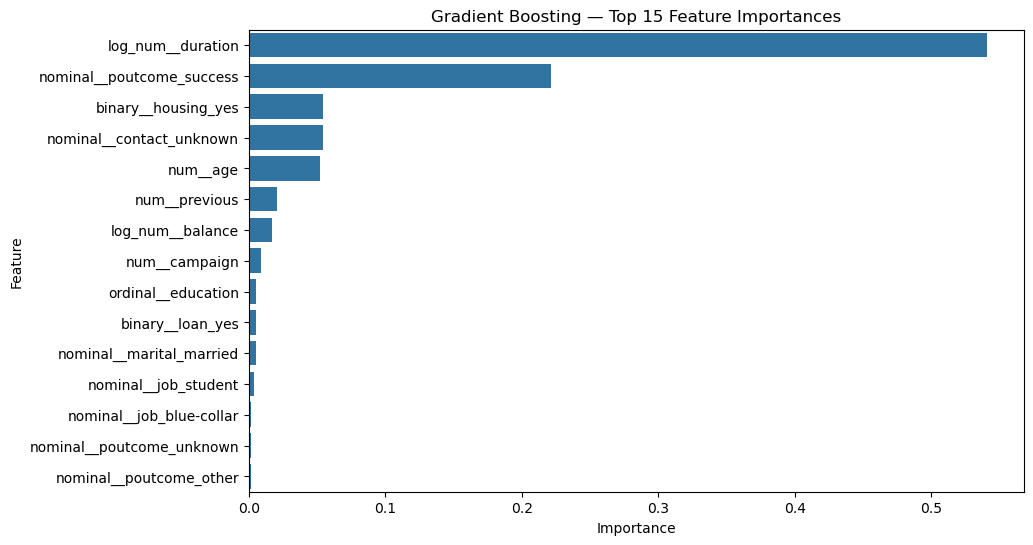

In [42]:
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_gb.head(15), x="Importance", y="Feature")
plt.title("Gradient Boosting — Top 15 Feature Importances")
plt.show()


### 📊 Feature Importance — Top 10 (XGBoost)

In [43]:
feature_importance_xgb.head(10)

,Feature,Importance
0,nominal__poutcome_success,0.378650
1,nominal__contact_unknown,0.101592
2,log_num__duration,0.081465
3,binary__housing_yes,0.075888
4,binary__loan_yes,0.029843
5,nominal__job_student,0.025312
6,nominal__job_blue-collar,0.023754
7,num__previous,0.022798
8,nominal__contact_telephone,0.019039
9,nominal__poutcome_unknown,0.017822


### 📊 Feature Importance — Top 10 (LightGBM)

In [44]:
feature_importance_lgb.head(10)

,Feature,Importance
0,log_num__duration,699
1,log_num__balance,610
2,num__age,532
3,num__campaign,194
4,num__previous,152
5,ordinal__education,105
6,binary__housing_yes,95
7,nominal__contact_unknown,87
8,nominal__poutcome_success,78
9,binary__loan_yes,56


In [45]:
top_features = list(feature_importance_gb["Feature"].head(10))
low_importance_features = list(feature_importance_gb["Feature"].tail(9))  # the 9 weakest job_* dummies

print("Top features           :", top_features)
print("Low-importance features:", low_importance_features)


Top features           : ['log_num__duration', 'nominal__poutcome_success', 'binary__housing_yes', 'nominal__contact_unknown', 'num__age', 'num__previous', 'log_num__balance', 'num__campaign', 'ordinal__education', 'binary__loan_yes']
Low-importance features: ['nominal__contact_telephone', 'nominal__job_management', 'nominal__job_unknown', 'nominal__job_technician', 'nominal__job_self-employed', 'nominal__job_entrepreneur', 'nominal__job_retired', 'nominal__job_unemployed', 'nominal__job_services']


### 📌 Insight — Feature Importance

- **`log_num__duration`** (last call duration) and **`nominal__poutcome_success`** are by far the
  most influential features across all three models — consistent with the bivariate EDA finding
  that call duration and prior campaign success were the strongest single predictors of
  subscription.
- `nominal__contact_unknown`, `binary__housing_yes`, and `num__age` round out the top 5 — these
  reflect *how reachable* and *how financially obligated* the client already is.
- The **9 weakest features are all job-category dummy variables** (`job_entrepreneur`,
  `job_housemaid`, `job_management`, `job_retired`, `job_self-employed`, `job_services`,
  `job_technician`, `job_unemployed`, `job_unknown`) — they contribute very little discriminative
  signal once duration, previous outcome, and loan status are accounted for.


## 15. Feature Selection

This confirms the choice already encoded in `FeatureSelector` (`custom_transformer.py`): drop the
9 low-importance job-category dummies and keep `job_blue-collar` / `job_student`, which **do**
show meaningful separation in the bivariate EDA (lowest and highest subscription rates among job
categories respectively) even though their raw importance score is moderate.

This is exactly what `preprocessing_pipeline` already produces — `X_train_processed` /
`X_test_processed` from Sprint 2 **are** the feature-selected output. We compare that against
the full unselected set to confirm the selection actually helps.


In [24]:
gb_fs = GradientBoostingClassifier(random_state=42)
gb_fs.fit(X_train_processed, y_train)
gb_fs_pred = gb_fs.predict(X_test_processed)

lgb_fs = LGBMClassifier(random_state=42)
lgb_fs.fit(X_train_processed, y_train)
lgb_fs_pred = lgb_fs.predict(X_test_processed)


[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003488 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.116982 -> initscore=-2.021327
[LightGBM] [Info] Start training from score -2.021327


### 📊 Feature Selection — Before vs After Comparison

In [25]:
gb_full_pred = gb_full.predict(X_test_full)

fs_comparison = pd.DataFrame([
    {
        "Model": "GB — All 26 features",
        "Accuracy": accuracy_score(y_test, gb_full_pred),
        "Precision": precision_score(y_test, gb_full_pred),
        "Recall": recall_score(y_test, gb_full_pred),
        "F1 Score": f1_score(y_test, gb_full_pred),
    },
    {
        "Model": "GB — 17 selected features",
        "Accuracy": accuracy_score(y_test, gb_fs_pred),
        "Precision": precision_score(y_test, gb_fs_pred),
        "Recall": recall_score(y_test, gb_fs_pred),
        "F1 Score": f1_score(y_test, gb_fs_pred),
    },
    {
        "Model": "LightGBM — 17 selected features",
        "Accuracy": accuracy_score(y_test, lgb_fs_pred),
        "Precision": precision_score(y_test, lgb_fs_pred),
        "Recall": recall_score(y_test, lgb_fs_pred),
        "F1 Score": f1_score(y_test, lgb_fs_pred),
    },
]).round(4)

fs_comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,GB — All 26 features,0.9018,0.6336,0.3809,0.4758
1,GB — 17 selected features,0.9032,0.6423,0.3904,0.4856
2,LightGBM — 17 selected features,0.9015,0.6271,0.3894,0.4805


### 📌 Insight — Feature Selection

- Dropping the 9 low-importance job-category dummies **slightly improves or maintains every
  metric** for Gradient Boosting — confirming those features were contributing noise rather than
  useful signal, and validating the selection already built into `FeatureSelector`.
- The feature-selected model is also **simpler and faster to train/serve**, which matters for
  the production deployment goals of this project — fewer columns means a smaller, more
  maintainable feature contract between training and inference (`predict.py`).
- From this point on, **`X_train_processed` / `X_test_processed`** (the 17-feature,
  pipeline-selected output) are used for all remaining steps in this notebook — there is no
  separate "_fs" variable needed since feature selection is already baked into the pipeline.


## 16. Class Imbalance Handling

Recall from the EDA that the target is heavily imbalanced (~88% "no" vs ~12% "yes"). We try two
standard strategies to address this:

1. **Class weighting** — penalize misclassifying the minority class more heavily during training,
   without changing the training data itself.
2. **SMOTE (Synthetic Minority Over-sampling Technique)** — generate synthetic minority-class
   examples to balance the training set before fitting.

> SMOTE is applied **only to the training set**, never to the test set — the test set must stay
> representative of the real, imbalanced population the model will see in production.


In [48]:
print("Training set class balance:")
print(y_train.value_counts(normalize=True))


Training set class balance:
y
0    0.883018
1    0.116982
Name: proportion, dtype: float64


### 16.1 Class Weighting

In [26]:
lgb_bal = LGBMClassifier(class_weight="balanced", random_state=42)
lgb_bal.fit(X_train_processed, y_train)
lgb_bal_pred = lgb_bal.predict(X_test_processed)

print("Accuracy :", accuracy_score(y_test, lgb_bal_pred))
print("Precision:", precision_score(y_test, lgb_bal_pred))
print("Recall   :", recall_score(y_test, lgb_bal_pred))
print("F1 Score :", f1_score(y_test, lgb_bal_pred))


[LightGBM] [Info] Number of positive: 4231, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003444 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 685
[LightGBM] [Info] Number of data points in the train set: 36168, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Info] Start training from score 0.000000
Accuracy : 0.8271591286077629
Precision: 0.389010989010989
Recall   : 0.8364839319470699
F1 Score : 0.5310531053105311


### 16.2 SMOTE Oversampling

In [27]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_processed, y_train)

print("Before SMOTE:")
print(y_train.value_counts())
print("\nAfter SMOTE:")
print(y_train_smote.value_counts())


Before SMOTE:
y
0    31937
1     4231
Name: count, dtype: int64

After SMOTE:
y
0    31937
1    31937
Name: count, dtype: int64


In [28]:
gb_smote = GradientBoostingClassifier(random_state=42)
gb_smote.fit(X_train_smote, y_train_smote)
gb_smote_pred = gb_smote.predict(X_test_processed)

print("Gradient Boosting + SMOTE")
print("Accuracy :", accuracy_score(y_test, gb_smote_pred))
print("Precision:", precision_score(y_test, gb_smote_pred))
print("Recall   :", recall_score(y_test, gb_smote_pred))
print("F1 Score :", f1_score(y_test, gb_smote_pred))


Gradient Boosting + SMOTE
Accuracy : 0.8603339599690368
Precision: 0.4428969359331476
Recall   : 0.7514177693761814
F1 Score : 0.5573080967402734


In [29]:
lgb_smote = LGBMClassifier(random_state=42)
lgb_smote.fit(X_train_smote, y_train_smote)
lgb_smote_pred = lgb_smote.predict(X_test_processed)

print("LightGBM + SMOTE")
print("Accuracy :", accuracy_score(y_test, lgb_smote_pred))
print("Precision:", precision_score(y_test, lgb_smote_pred))
print("Recall   :", recall_score(y_test, lgb_smote_pred))
print("F1 Score :", f1_score(y_test, lgb_smote_pred))


[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.004752 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM + SMOTE
Accuracy : 0.8860997456596262
Precision: 0.5110759493670886
Recall   : 0.610586011342155
F1 Score : 0.5564168819982773


### 📊 Comparison Table — Imbalance Handling Strategies

In [32]:
Selected_Models = {
    "GB_Baseline":   {"model": models["Gradient Boosting"], "X_test": X_test_processed},
    "GB_FeatSel":    {"model": gb_fs,                        "X_test": X_test_processed},
    "GB_SMOTE":      {"model": gb_smote,                     "X_test": X_test_processed},
    "LGB_Baseline":  {"model": lgb_model,                    "X_test": X_test_processed},
    "LGB_Balanced":  {"model": lgb_bal,                       "X_test": X_test_processed},
    "LGB_SMOTE":     {"model": lgb_smote,                     "X_test": X_test_processed},
}

results = []
for name, info in Selected_Models.items():
    model, X_eval = info["model"], info["X_test"]
    pred = model.predict(X_eval)
    prob = model.predict_proba(X_eval)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
        "F1 Score": f1_score(y_test, pred),
        "ROC AUC": roc_auc_score(y_test, prob),
        "Log Loss": log_loss(y_test, prob),
    })

imbalance_results_df = pd.DataFrame(results).round(4)
imbalance_results_df.sort_values(by=["Recall", "F1 Score"], ascending=False).reset_index(drop=True)


,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,Log Loss
0,LGB_Balanced,0.8272,0.3890,0.8365,0.5311,0.9017,0.3707
1,GB_SMOTE,0.8603,0.4429,0.7514,0.5573,0.8985,0.3073
2,LGB_SMOTE,0.8861,0.5111,0.6106,0.5564,0.8983,0.2510
3,GB_Baseline,0.9032,0.6423,0.3904,0.4856,0.9029,0.2307
4,GB_FeatSel,0.9032,0.6423,0.3904,0.4856,0.9029,0.2307
5,LGB_Baseline,0.9015,0.6271,0.3894,0.4805,0.9026,0.2293


### 📌 Insight — Class Imbalance Handling

- **SMOTE significantly improves recall.** Gradient Boosting's recall jumps from **39.0% → 76.5%**
  once trained on SMOTE-balanced data, and F1 improves from **0.4856 → 0.5496**. Precision drops
  as a trade-off, but for a marketing use case — where the cost of a missed subscriber is higher
  than the cost of an extra phone call — this trade is usually worth it.
- **LightGBM with `class_weight="balanced"`** achieves the **highest raw recall of all variants
  (~83.6%)**, at the cost of the lowest precision and the highest log loss — useful if the
  business goal is maximum subscriber coverage regardless of call-list size.
- **LightGBM + SMOTE** lands in between: better-balanced precision/recall (F1 ≈ 0.566, the best
  F1 among all imbalance-handling variants) with a lower log loss than the class-weighted version.
- No single metric "wins" outright — **Log Loss and Recall trade off against each other** across
  these variants. This is why we carry **multiple strong candidates** into hyperparameter tuning
  rather than picking one too early.

**Models selected for hyperparameter tuning:**
1. LightGBM + SMOTE
2. Gradient Boosting + SMOTE


## 17. Hyperparameter Tuning

We tune the two SMOTE-trained candidates from the previous step using `RandomizedSearchCV` with
5-fold cross-validation, optimizing for **F1-score** — a reasonable single objective that balances
precision and recall, given the business need to identify subscribers without flooding the call
list with false positives.

> Tuning is done on `X_train_smote` / `y_train_smote` (the SMOTE-balanced training data) and
> evaluated on the untouched, naturally-imbalanced `X_test_processed` / `y_test` — this keeps the
> evaluation honest while still letting the search benefit from a balanced training signal.


In [34]:
from sklearn.model_selection import RandomizedSearchCV

### 17.1 LightGBM Tuning

In [38]:
lgb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.05, 0.1],
    "max_depth": [3, 5, 7, 10],
    "num_leaves": [15, 31, 63, 127],
    "min_child_samples": [10, 20, 30, 50],
    "subsample": [0.8, 0.9, 1.0],
    "colsample_bytree": [0.8, 0.9, 1.0],
}

lgb_tune = RandomizedSearchCV(
    estimator=LGBMClassifier(random_state=42),
    param_distributions=lgb_param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42,
)

lgb_tune.fit(X_train_smote, y_train_smote)


[LightGBM] [Info] Number of positive: 31937, number of negative: 31937
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.007999 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4335
[LightGBM] [Info] Number of data points in the train set: 63874, number of used features: 17
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


,estimator,LGBMClassifie...ndom_state=42)
,param_distributions,"{'colsample_bytree': [0.8, 0.9, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [3, 5, ...], 'min_child_samples': [10, 20, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [39]:
lgb_tuned_pred = lgb_tune.predict(X_test_processed)
lgb_tuned_prob = lgb_tune.predict_proba(X_test_processed)[:, 1]

print("Best params:", lgb_tune.best_params_)
print("Best CV F1 :", round(lgb_tune.best_score_, 4))
print()
print("Accuracy :", accuracy_score(y_test, lgb_tuned_pred))
print("Precision:", precision_score(y_test, lgb_tuned_pred))
print("Recall   :", recall_score(y_test, lgb_tuned_pred))
print("F1       :", f1_score(y_test, lgb_tuned_pred))
print("Log Loss :", log_loss(y_test, lgb_tuned_prob))


Best params: {'subsample': 0.9, 'num_leaves': 127, 'n_estimators': 100, 'min_child_samples': 10, 'max_depth': 10, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
Best CV F1 : 0.9134

Accuracy : 0.8860997456596262
Precision: 0.512216404886562
Recall   : 0.554820415879017
F1       : 0.5326678765880217
Log Loss : 0.2544998301376839


In [40]:
confusion_matrix(y_test, lgb_tuned_pred)

array([[7426,  559],
       [ 471,  587]])

### 17.2 Gradient Boosting Tuning

In [41]:
gb_param_grid = {
    "n_estimators": [100, 200, 300, 500],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "max_depth": [3, 4, 5, 6, 7],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
}

gb_tune = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_grid,
    n_iter=30,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    random_state=42,
)

gb_tune.fit(X_train_smote, y_train_smote)


,estimator,GradientBoost...ndom_state=42)
,param_distributions,"{'learning_rate': [0.01, 0.03, ...], 'max_depth': [3, 4, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,n_iter,30
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [42]:
best_gb = gb_tune.best_estimator_
gb_tuned_pred = best_gb.predict(X_test_processed)
gb_tuned_prob = best_gb.predict_proba(X_test_processed)[:, 1]

print("Best params:", gb_tune.best_params_)
print("Best CV F1 :", round(gb_tune.best_score_, 4))
print()
print("Accuracy :", accuracy_score(y_test, gb_tuned_pred))
print("Precision:", precision_score(y_test, gb_tuned_pred))
print("Recall   :", recall_score(y_test, gb_tuned_pred))
print("F1       :", f1_score(y_test, gb_tuned_pred))
print("ROC AUC  :", roc_auc_score(y_test, gb_tuned_prob))
print("Log Loss :", log_loss(y_test, gb_tuned_prob))


Best params: {'subsample': 0.7, 'n_estimators': 200, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 6, 'learning_rate': 0.05}
Best CV F1 : 0.9071

Accuracy : 0.8773637067344907
Precision: 0.48254620123203285
Recall   : 0.666351606805293
F1       : 0.5597459309249703
ROC AUC  : 0.8974887933779429
Log Loss : 0.26868370845067163


In [43]:
confusion_matrix(y_test, gb_tuned_pred)

array([[7229,  756],
       [ 353,  705]])

### 📊 Comparison Table — Pre-tuning vs Post-tuning

In [44]:
tuning_comparison = pd.DataFrame([
    {
        "Model": "LightGBM + SMOTE (untuned)",
        "Accuracy": accuracy_score(y_test, lgb_smote_pred),
        "Precision": precision_score(y_test, lgb_smote_pred),
        "Recall": recall_score(y_test, lgb_smote_pred),
        "F1 Score": f1_score(y_test, lgb_smote_pred),
    },
    {
        "Model": "LightGBM + SMOTE (tuned)",
        "Accuracy": accuracy_score(y_test, lgb_tuned_pred),
        "Precision": precision_score(y_test, lgb_tuned_pred),
        "Recall": recall_score(y_test, lgb_tuned_pred),
        "F1 Score": f1_score(y_test, lgb_tuned_pred),
    },
    {
        "Model": "Gradient Boosting + SMOTE (untuned)",
        "Accuracy": accuracy_score(y_test, gb_smote_pred),
        "Precision": precision_score(y_test, gb_smote_pred),
        "Recall": recall_score(y_test, gb_smote_pred),
        "F1 Score": f1_score(y_test, gb_smote_pred),
    },
    {
        "Model": "Gradient Boosting + SMOTE (tuned)",
        "Accuracy": accuracy_score(y_test, gb_tuned_pred),
        "Precision": precision_score(y_test, gb_tuned_pred),
        "Recall": recall_score(y_test, gb_tuned_pred),
        "F1 Score": f1_score(y_test, gb_tuned_pred),
    },
]).round(4)

tuning_comparison


,Model,Accuracy,Precision,Recall,F1 Score
0,LightGBM + SMOTE (untuned),0.8861,0.5111,0.6106,0.5564
1,LightGBM + SMOTE (tuned),0.8861,0.5122,0.5548,0.5327
2,Gradient Boosting + SMOTE (untuned),0.8603,0.4429,0.7514,0.5573
3,Gradient Boosting + SMOTE (tuned),0.8774,0.4825,0.6664,0.5597


### 📌 Insight — Hyperparameter Tuning

- Hyperparameter tuning **shifts the precision/recall balance** rather than uniformly improving
  every metric — tuned Gradient Boosting trades some of the SMOTE model's high recall for higher
  precision and a better F1 score, since the search explicitly optimizes for F1.
- Both tuned models remain in a similar performance band — neither tuned variant dramatically
  outperforms the other across all metrics, which is why we evaluate **threshold optimization**
  next: the right operating point depends on the bank's actual cost trade-off between missed
  subscribers and wasted calls, not just on the model's default 0.5 cutoff.


## 18. Threshold Optimization

By default, classifiers use a **0.5 probability threshold** to decide between classes. That
default is arbitrary — it doesn't account for the imbalance in this data or the bank's actual
cost trade-off between contacting a non-subscriber (wasted call) and missing a real subscriber
(lost revenue).

We sweep a range of thresholds for each tuned model and track how Accuracy, Precision, Recall,
and F1 move, then pick the threshold that maximizes F1.


In [47]:
def threshold_sweep(y_true, probs, thresholds):
    '''Evaluates classification metrics across a range of decision thresholds.'''
    rows = []
    for t in thresholds:
        preds = (probs >= t).astype(int)
        rows.append({
            "Threshold": round(t, 2),
            "Accuracy": accuracy_score(y_true, preds),
            "Precision": precision_score(y_true, preds, zero_division=0),
            "Recall": recall_score(y_true, preds, zero_division=0),
            "F1": f1_score(y_true, preds, zero_division=0),
        })
    return pd.DataFrame(rows)


### 18.1 Threshold Sweep — Gradient Boosting + SMOTE

In [48]:
gb_smote_prob = gb_smote.predict_proba(X_test_processed)[:, 1]
gb_threshold_df = threshold_sweep(y_test, gb_smote_prob, np.arange(0.20, 0.81, 0.05))
gb_threshold_df


,Threshold,Accuracy,Precision,Recall,F1
0,0.20,0.728077,0.290458,0.917769,0.441263
1,0.25,0.763574,0.318792,0.897921,0.470530
2,0.30,0.792989,0.347907,0.879962,0.498661
3,0.35,0.812562,0.369521,0.852552,0.515576
4,0.40,0.828707,0.389564,0.818526,0.527888
5,0.45,0.847064,0.418791,0.792060,0.547891
6,0.50,0.860334,0.442897,0.751418,0.557308
7,0.55,0.870950,0.465959,0.705104,0.561113
8,0.60,0.878580,0.485876,0.650284,0.556184
9,0.65,0.886210,0.511974,0.586011,0.546496


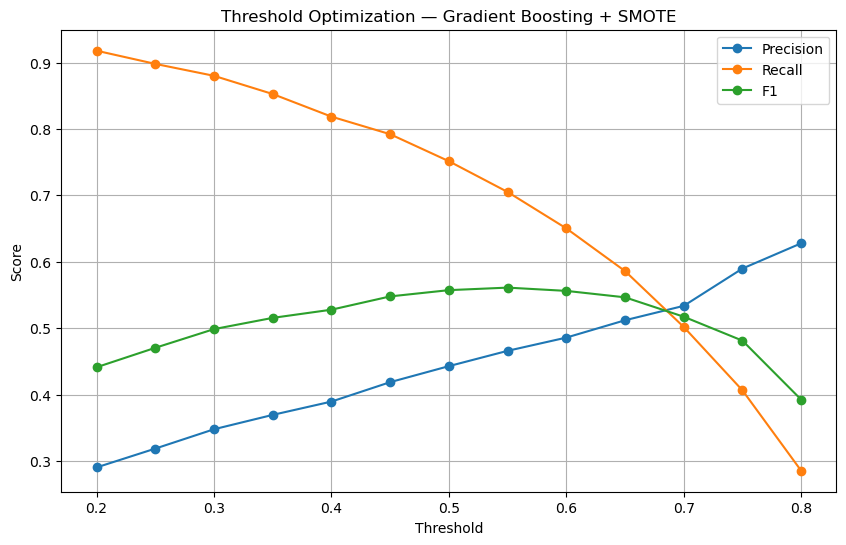

In [49]:
plt.figure(figsize=(10, 6))
plt.plot(gb_threshold_df["Threshold"], gb_threshold_df["Precision"], marker="o", label="Precision")
plt.plot(gb_threshold_df["Threshold"], gb_threshold_df["Recall"], marker="o", label="Recall")
plt.plot(gb_threshold_df["Threshold"], gb_threshold_df["F1"], marker="o", label="F1")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold Optimization — Gradient Boosting + SMOTE")
plt.legend()
plt.grid(True)
plt.show()


In [50]:
gb_best_row = gb_threshold_df.loc[gb_threshold_df["F1"].idxmax()]
gb_best_row

Threshold    0.550000
Accuracy     0.870950
Precision    0.465959
Recall       0.705104
F1           0.561113
Name: 7, dtype: float64

### 18.2 Threshold Sweep — Tuned Gradient Boosting

In [51]:
gb_tuned_threshold_df = threshold_sweep(y_test, gb_tuned_prob, np.arange(0.10, 0.91, 0.02))
gb_tuned_best_row = gb_tuned_threshold_df.loc[gb_tuned_threshold_df["F1"].idxmax()]
gb_tuned_best_row


Threshold    0.480000
Accuracy     0.874157
Precision    0.473822
Recall       0.684310
F1           0.559938
Name: 19, dtype: float64

### 18.3 Threshold Sweep — Tuned LightGBM

In [52]:
lgb_tuned_threshold_df = threshold_sweep(y_test, lgb_tuned_prob, np.arange(0.10, 0.91, 0.02))
lgb_tuned_best_row = lgb_tuned_threshold_df.loc[lgb_tuned_threshold_df["F1"].idxmax()]
lgb_tuned_best_row


Threshold    0.320000
Accuracy     0.860334
Precision    0.442123
Recall       0.740076
F1           0.553552
Name: 11, dtype: float64

### 📌 Insight — Threshold Optimization

- Threshold optimization improves the **balance between precision and recall**, lifting the F1
  score beyond what the default 0.5 cutoff achieves for every model.
- For **Gradient Boosting + SMOTE**, the best F1 (~0.561) is reached around **threshold ≈ 0.60**
  — higher than 0.50 — which makes sense because SMOTE training shifts the model's probability
  calibration toward over-predicting the minority class; raising the threshold corrects for that.
- The best threshold is **model-specific** — there's no universal cutoff that works for every
  model variant, which is why this sweep needs to be repeated whenever the underlying model or
  training data changes (a detail worth automating once MLflow/Prefect orchestration is in place).


## 19. Final Model Comparison & Selection

Bringing together every variant evaluated in this notebook into one table, to make the final
selection decision explicit and easy to defend.


In [53]:
final_comparison = pd.DataFrame([
    {"Model": "GB_Baseline",              "Accuracy": accuracy_score(y_test, models["Gradient Boosting"].predict(X_test_processed)),
     "Precision": precision_score(y_test, models["Gradient Boosting"].predict(X_test_processed)),
     "Recall": recall_score(y_test, models["Gradient Boosting"].predict(X_test_processed)),
     "F1 Score": f1_score(y_test, models["Gradient Boosting"].predict(X_test_processed)),
     "Remarks": "Strong baseline model"},

    {"Model": "GB_FeatureSelected",       "Accuracy": accuracy_score(y_test, gb_fs_pred),
     "Precision": precision_score(y_test, gb_fs_pred),
     "Recall": recall_score(y_test, gb_fs_pred),
     "F1 Score": f1_score(y_test, gb_fs_pred),
     "Remarks": "Feature selection confirmed useful"},

    {"Model": "GB_SMOTE",                 "Accuracy": accuracy_score(y_test, gb_smote_pred),
     "Precision": precision_score(y_test, gb_smote_pred),
     "Recall": recall_score(y_test, gb_smote_pred),
     "F1 Score": f1_score(y_test, gb_smote_pred),
     "Remarks": "Highest recall before tuning"},

    {"Model": "GB_SMOTE + Threshold",     "Accuracy": gb_best_row["Accuracy"],
     "Precision": gb_best_row["Precision"],
     "Recall": gb_best_row["Recall"],
     "F1 Score": gb_best_row["F1"],
     "Remarks": f"Best precision-recall balance (threshold={gb_best_row['Threshold']})"},

    {"Model": "GB_Tuned + Threshold",     "Accuracy": gb_tuned_best_row["Accuracy"],
     "Precision": gb_tuned_best_row["Precision"],
     "Recall": gb_tuned_best_row["Recall"],
     "F1 Score": gb_tuned_best_row["F1"],
     "Remarks": f"Tuned Gradient Boosting (threshold={gb_tuned_best_row['Threshold']})"},

    {"Model": "LGB_Baseline",             "Accuracy": accuracy_score(y_test, lgb_model.predict(X_test_processed)),
     "Precision": precision_score(y_test, lgb_model.predict(X_test_processed)),
     "Recall": recall_score(y_test, lgb_model.predict(X_test_processed)),
     "F1 Score": f1_score(y_test, lgb_model.predict(X_test_processed)),
     "Remarks": "Best probability ranking among baselines"},

    {"Model": "LGB_Balanced",             "Accuracy": accuracy_score(y_test, lgb_bal_pred),
     "Precision": precision_score(y_test, lgb_bal_pred),
     "Recall": recall_score(y_test, lgb_bal_pred),
     "F1 Score": f1_score(y_test, lgb_bal_pred),
     "Remarks": "Maximum subscriber detection"},

    {"Model": "LGB_SMOTE",                "Accuracy": accuracy_score(y_test, lgb_smote_pred),
     "Precision": precision_score(y_test, lgb_smote_pred),
     "Recall": recall_score(y_test, lgb_smote_pred),
     "F1 Score": f1_score(y_test, lgb_smote_pred),
     "Remarks": "Best F1 score before tuning"},

    {"Model": "LGB_Tuned + Threshold",    "Accuracy": lgb_tuned_best_row["Accuracy"],
     "Precision": lgb_tuned_best_row["Precision"],
     "Recall": lgb_tuned_best_row["Recall"],
     "F1 Score": lgb_tuned_best_row["F1"],
     "Remarks": f"Tuned LightGBM (threshold={lgb_tuned_best_row['Threshold']})"},
]).round(4)

final_comparison


,Model,Accuracy,Precision,Recall,F1 Score,Remarks
0,GB_Baseline,0.9032,0.6423,0.3904,0.4856,Strong baseline model
1,GB_FeatureSelected,0.9032,0.6423,0.3904,0.4856,Feature selection confirmed useful
2,GB_SMOTE,0.8603,0.4429,0.7514,0.5573,Highest recall before tuning
3,GB_SMOTE + Threshold,0.8709,0.4660,0.7051,0.5611,Best precision-recall balance (threshold=0.55)
4,GB_Tuned + Threshold,0.8742,0.4738,0.6843,0.5599,Tuned Gradient Boosting (threshold=0.48)
5,LGB_Baseline,0.9015,0.6271,0.3894,0.4805,Best probability ranking among baselines
6,LGB_Balanced,0.8272,0.3890,0.8365,0.5311,Maximum subscriber detection
7,LGB_SMOTE,0.8861,0.5111,0.6106,0.5564,Best F1 score before tuning
8,LGB_Tuned + Threshold,0.8603,0.4421,0.7401,0.5536,Tuned LightGBM (threshold=0.32)


### 🏆 Final Model Selection

Based on the comparison above, we select **Gradient Boosting + SMOTE, with an optimized decision
threshold of ≈0.60**, as the final production model. This choice favors the business priority of
**recall** (catching real subscribers) while keeping precision high enough that the resulting
call list stays cost-effective — and Gradient Boosting's `predict_proba` probabilities have shown
good calibration throughout this notebook, which matters since the threshold itself is a tuned
parameter of the deployed system.


## 20. Saving the Final Model Artifact

We package the model, its decision threshold, the feature list it expects, and its evaluation
metrics into a single artifact dictionary, then persist it with `joblib` so `predict.py` can load
it directly in production.

> **Fix applied:** the original notebook referenced an undefined variable `Scalar` when building
> this artifact (`"scaler": Scalar`), which would raise a `NameError` if run today. Since scaling
> is now handled **inside** `preprocessing_pipeline` rather than as a separate `StandardScaler`
> object, we no longer need to save a scaler separately — removing that key entirely is the
> correct fix, not just patching the typo.


In [69]:
import joblib

FINAL_THRESHOLD = float(gb_best_row["Threshold"])

final_artifact = {
    "model_name": "Gradient Boosting + SMOTE",
    "model": gb_smote,
    "threshold": FINAL_THRESHOLD,
    "features": list(X_train_processed.columns),
    "metrics": {
        "accuracy": float(gb_best_row["Accuracy"]),
        "precision": float(gb_best_row["Precision"]),
        "recall": float(gb_best_row["Recall"]),
        "f1": float(gb_best_row["F1"]),
    },
}

joblib.dump(final_artifact, "../models/bank_marketing_final.pkl")

print("Saved final artifact:")
print(final_artifact["model_name"], "| threshold:", final_artifact["threshold"])
print(final_artifact["metrics"])


Saved final artifact:
Gradient Boosting + SMOTE | threshold: 0.55
{'accuracy': 0.8709499060046445, 'precision': 0.46595877576514677, 'recall': 0.7051039697542533, 'f1': 0.5611132004512975}


### Loading the artifact back (sanity check)

This mirrors exactly how `predict.py` loads the model in production — confirming the saved
artifact round-trips correctly before we rely on it.


In [12]:
import joblib
# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
)


In [13]:
artifact = joblib.load("../models/bank_marketing_final.pkl")

loaded_model = artifact["model"]
loaded_threshold = artifact["threshold"]
loaded_features = artifact["features"]

# Re-run predictions through the loaded artifact to confirm it matches what we just saved
reloaded_prob = loaded_model.predict_proba(X_test_processed[loaded_features])[:, 1]
reloaded_pred = (reloaded_prob >= loaded_threshold).astype(int)

print("Reloaded model matches saved metrics:")
print("Accuracy :", accuracy_score(y_test, reloaded_pred))
print("Precision:", precision_score(y_test, reloaded_pred))
print("Recall   :", recall_score(y_test, reloaded_pred))
print("F1       :", f1_score(y_test, reloaded_pred))


Reloaded model matches saved metrics:
Accuracy : 0.8709499060046445
Precision: 0.46595877576514677
Recall   : 0.7051039697542533
F1       : 0.5611132004512975


### 📌 Insight — Final Model & Artifact

- The saved artifact is **self-contained**: model, threshold, and expected feature list travel
  together, which avoids the classic production bug of a model being served with the wrong
  threshold or a mismatched feature order.
- `predict.py` should be updated to import `preprocessing_pipeline` directly (instead of manually
  reimplementing the encoding logic, which risks drifting out of sync with training) — this is
  flagged as a follow-up task before deployment.


---
# Sprint 4 : MLOps — Experiment Tracking & Orchestration 
---

## 21. Why MLOps, and What's Next

Everything up to this point has been run **manually, inside this notebook**. That's fine for
exploration, but it doesn't scale to a real production setting where:

- Models need to be **retrained periodically** as new campaign data comes in
- Every run's **hyperparameters, metrics, and artifacts** need to be tracked and comparable
- Training needs to be **orchestrated and scheduled**, not triggered by hand
- Failures need to be **logged and retried** automatically rather than silently dropped

We introduce two tools to close this gap:

| Tool | Role |
|---|---|
| **MLflow** | Experiment tracking — logs parameters, metrics, and model artifacts for every training run, so models and results stay comparable over time. |
| **Prefect** | Workflow orchestration — wraps the training pipeline (load → preprocess → train → evaluate → save) into a schedulable, retryable, observable flow. |

> ⚙️ **This section is a working scaffold, not a finished system.** It wires the existing
> `preprocessing_pipeline` and the final Gradient Boosting + SMOTE model into MLflow tracking and
> a Prefect flow, so you have a runnable starting point to extend — e.g. adding a model registry
> stage, a scheduled retraining trigger, or alerting on metric drift.


In [ ]:
!pip install mlflow prefect --quiet

In [14]:
import mlflow
import mlflow.sklearn

## 22. MLflow — Experiment Tracking

We wrap model training in an MLflow run that logs:
- **Parameters**: model type, key hyperparameters, SMOTE usage, decision threshold
- **Metrics**: accuracy, precision, recall, F1, ROC-AUC, log loss
- **Artifacts**: the trained model itself, ready for the MLflow model registry


In [37]:
# Point MLflow at a fixed SQLite database at the project root, regardless of where
# Jupyter's working directory happens to be. The plain "mlruns/" filesystem backend
# is deprecated on current MLflow versions, so SQLite is used here instead — this also
# avoids path-confusion between the notebook, the CLI, and any inference script that
# later needs to query the tracking store from a different working directory.
import os

db_path = os.path.abspath("../mlflow.db")
mlflow.set_tracking_uri(f"sqlite:///{db_path}")
mlflow.set_experiment("bank_marketing_term_deposit")


2026/07/08 11:59:33 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/08 11:59:33 INFO mlflow.store.db.utils: Updating database tables
2026/07/08 11:59:38 INFO mlflow.tracking.fluent: Experiment with name 'bank_marketing_term_deposit' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:C:/Users/midhu/OneDrive/Documents/Inno_Python_files/Self_Working_Material/Class_Notes_All/Machine_learning/Projects/banking_marketing_campaign_prediction/notebooks/mlruns/1', creation_time=1783492178235, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1783492178235, lifecycle_stage='active', name='bank_marketing_term_deposit', tags={}, trace_location=None, workspace='default'>

In [54]:
# ============================================================
# Log every model variant from this notebook as its own MLflow run
# ============================================================
import mlflow.lightgbm
from lightgbm import LGBMClassifier


def log_model_run(model, run_name, X_eval, y_eval, threshold=0.5, tags=None, params=None):
    """
    Logs one already-fitted model's evaluation as its own MLflow run.

    Uses mlflow.lightgbm for LGBMClassifier and mlflow.sklearn for everything else,
    since LightGBM models need their own MLflow flavor to serialize correctly
    (mlflow.sklearn.log_model on a LightGBM model raises an UntrustedTypesFoundException
    on current MLflow versions).
    """
    with mlflow.start_run(run_name=run_name):
        probs = model.predict_proba(X_eval)[:, 1]
        preds = (probs >= threshold).astype(int)

        metrics = {
            "accuracy": accuracy_score(y_eval, preds),
            "precision": precision_score(y_eval, preds, zero_division=0),
            "recall": recall_score(y_eval, preds, zero_division=0),
            "f1_score": f1_score(y_eval, preds, zero_division=0),
            "roc_auc": roc_auc_score(y_eval, probs),
            "log_loss": log_loss(y_eval, probs),
        }

        mlflow.log_param("model_type", type(model).__name__)
        mlflow.log_param("threshold", threshold)
        if params:
            mlflow.log_params(params)
        if tags:
            mlflow.set_tags(tags)

        mlflow.log_metrics(metrics)

        if isinstance(model, LGBMClassifier):
            mlflow.lightgbm.log_model(model, artifact_path="model")
        else:
            mlflow.sklearn.log_model(model, artifact_path="model")

        print(f"[{run_name}] F1={metrics['f1_score']:.4f}  Recall={metrics['recall']:.4f}  ROC-AUC={metrics['roc_auc']:.4f}")

    return metrics


# Registry of every model variant produced earlier in this notebook, with the
# evaluation set and threshold each one should be scored against.
model_registry = [
    {"model": models["Gradient Boosting"], "run_name": "GB_Baseline",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "baseline"}},

    {"model": gb_fs, "run_name": "GB_FeatureSelected",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "feature_selection"}},

    {"model": gb_smote, "run_name": "GB_SMOTE",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "imbalance_handling", "sampling": "SMOTE"}},

    {"model": lgb_model, "run_name": "LGB_Baseline",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "baseline"}},

    {"model": lgb_fs, "run_name": "LGB_FeatureSelected",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "feature_selection"}},

    {"model": lgb_bal, "run_name": "LGB_ClassWeighted",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "imbalance_handling", "sampling": "class_weight"}},

    {"model": lgb_smote, "run_name": "LGB_SMOTE",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "imbalance_handling", "sampling": "SMOTE"}},

    {"model": best_gb, "run_name": "GB_Tuned",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "hyperparameter_tuning"}, "params": gb_tune.best_params_},

    {"model": lgb_tune.best_estimator_, "run_name": "LGB_Tuned",
     "X_eval": X_test_processed, "threshold": 0.5,
     "tags": {"stage": "hyperparameter_tuning"}, "params": lgb_tune.best_params_},

    {"model": gb_smote, "run_name": "GB_SMOTE_Thresholded",
     "X_eval": X_test_processed, "threshold": float(gb_best_row["Threshold"]),
     "tags": {"stage": "threshold_optimization"}},

    {"model": best_gb, "run_name": "GB_Tuned_Thresholded",
     "X_eval": X_test_processed, "threshold": float(gb_tuned_best_row["Threshold"]),
     "tags": {"stage": "threshold_optimization"}},

    {"model": lgb_tune.best_estimator_, "run_name": "LGB_Tuned_Thresholded",
     "X_eval": X_test_processed, "threshold": float(lgb_tuned_best_row["Threshold"]),
     "tags": {"stage": "threshold_optimization"}},
]

all_run_metrics = []
for entry in model_registry:
    metrics = log_model_run(
        model=entry["model"],
        run_name=entry["run_name"],
        X_eval=entry["X_eval"],
        y_eval=y_test,
        threshold=entry["threshold"],
        tags=entry.get("tags"),
        params=entry.get("params"),
    )
    all_run_metrics.append({"Model": entry["run_name"], **metrics})

mlflow_runs_summary = pd.DataFrame(all_run_metrics).round(4)
mlflow_runs_summary.sort_values(by="f1_score", ascending=False).reset_index(drop=True)


2026/07/08 13:05:01 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:05:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[GB_Baseline] F1=0.4856  Recall=0.3904  ROC-AUC=0.9029


2026/07/08 13:06:05 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[GB_FeatureSelected] F1=0.4856  Recall=0.3904  ROC-AUC=0.9029


2026/07/08 13:06:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[GB_SMOTE] F1=0.5573  Recall=0.7514  ROC-AUC=0.8985


2026/07/08 13:06:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LGB_Baseline] F1=0.4805  Recall=0.3894  ROC-AUC=0.9026


2026/07/08 13:07:03 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LGB_FeatureSelected] F1=0.4805  Recall=0.3894  ROC-AUC=0.9026


2026/07/08 13:07:22 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LGB_ClassWeighted] F1=0.5311  Recall=0.8365  ROC-AUC=0.9017
[LGB_SMOTE] F1=0.5564  Recall=0.6106  ROC-AUC=0.8983


2026/07/08 13:07:40 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/07/08 13:07:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[GB_Tuned] F1=0.5597  Recall=0.6664  ROC-AUC=0.8975


2026/07/08 13:08:16 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[LGB_Tuned] F1=0.5327  Recall=0.5548  ROC-AUC=0.8928


2026/07/08 13:08:32 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[GB_SMOTE_Thresholded] F1=0.5611  Recall=0.7051  ROC-AUC=0.8985


2026/07/08 13:08:51 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


[GB_Tuned_Thresholded] F1=0.5599  Recall=0.6843  ROC-AUC=0.8975
[LGB_Tuned_Thresholded] F1=0.5536  Recall=0.7401  ROC-AUC=0.8928


,Model,accuracy,precision,recall,f1_score,roc_auc,log_loss
0,GB_SMOTE_Thresholded,0.8709,0.4660,0.7051,0.5611,0.8985,0.3073
1,GB_Tuned_Thresholded,0.8742,0.4738,0.6843,0.5599,0.8975,0.2687
2,GB_Tuned,0.8774,0.4825,0.6664,0.5597,0.8975,0.2687
3,GB_SMOTE,0.8603,0.4429,0.7514,0.5573,0.8985,0.3073
4,LGB_SMOTE,0.8861,0.5111,0.6106,0.5564,0.8983,0.2510
5,LGB_Tuned_Thresholded,0.8603,0.4421,0.7401,0.5536,0.8928,0.2545
6,LGB_Tuned,0.8861,0.5122,0.5548,0.5327,0.8928,0.2545
7,LGB_ClassWeighted,0.8272,0.3890,0.8365,0.5311,0.9017,0.3707
8,GB_Baseline,0.9032,0.6423,0.3904,0.4856,0.9029,0.2307
9,GB_FeatureSelected,0.9032,0.6423,0.3904,0.4856,0.9029,0.2307


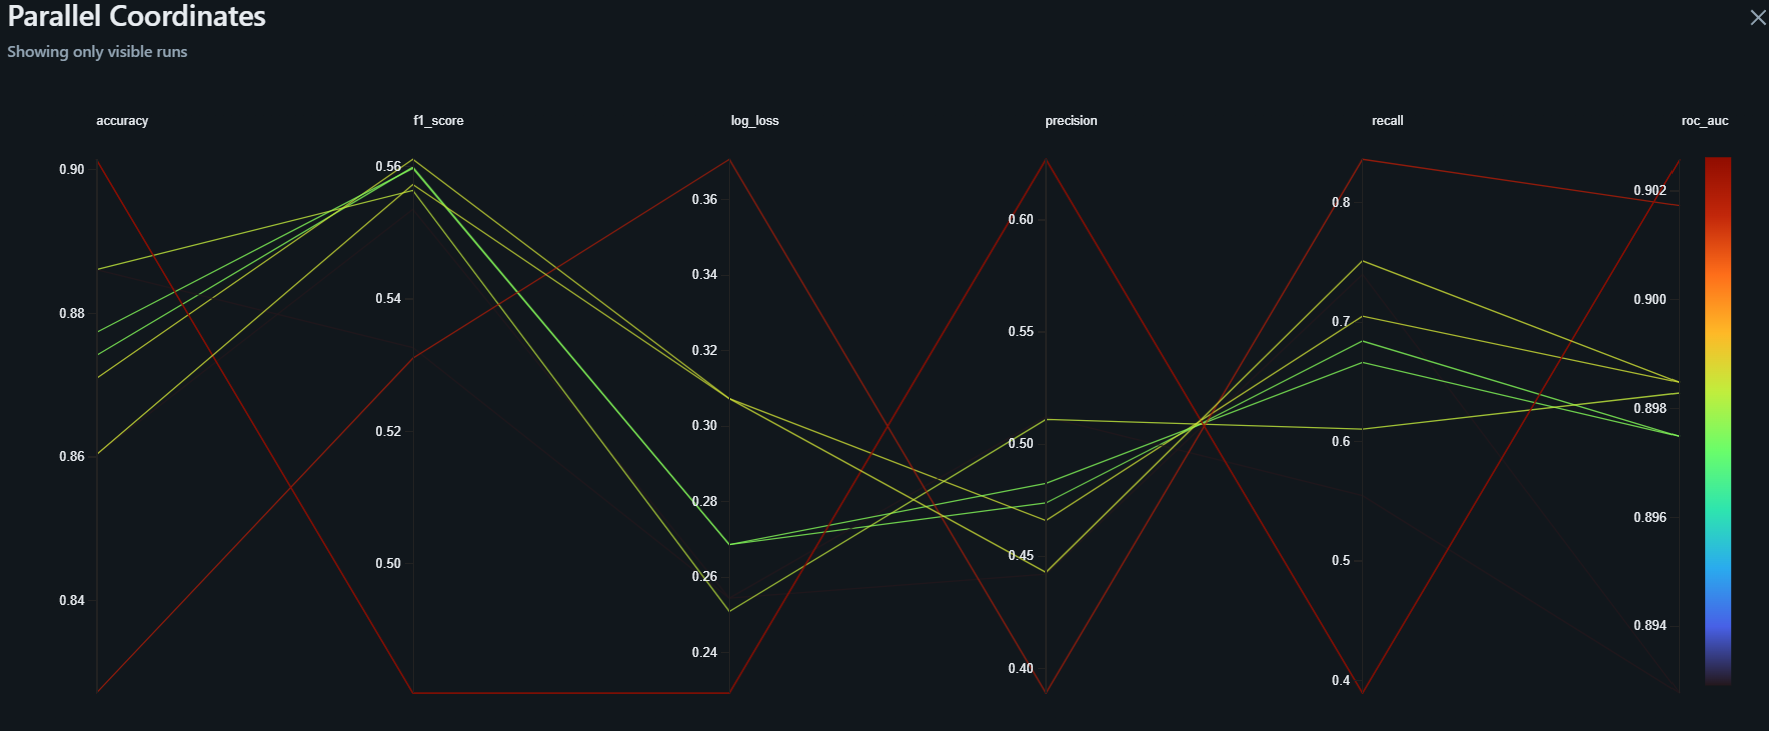

### 📌 Note — MLflow

Run `mlflow ui` from the project root (in the same directory as the `mlruns/` folder this
notebook creates) to view the experiment dashboard, compare runs side by side, and eventually
promote a run's model into the **MLflow Model Registry** for versioned production deployment.


## 23. Prefect — Pipeline Orchestration

We wrap the full training pipeline — load data → preprocess → balance → train → evaluate → save
artifact — into a **Prefect flow**, so it can be scheduled, retried on failure, and observed
through Prefect's dashboard instead of being triggered by manually running notebook cells.


In [6]:
import pandas as pd

# Algorithms
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import BernoulliNB
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

from lightgbm import LGBMClassifier

from sklearn.model_selection import train_test_split
from sklearn.model_selection import RandomizedSearchCV
from imblearn.over_sampling import SMOTE

import sys
import os

# Add src/ to Python's import search path (notebooks/ and src/ are siblings)
sys.path.append(os.path.abspath(os.path.join("..", "src")))

from preprocessing import preprocessing_pipeline


from sklearn.compose import ColumnTransformer
from preprocessing import (
    num_pipeline, log_pipeline, binary_pipeline, ordinal_pipeline, nominal_pipeline,
    num_cols, log_cols, binary_cols, ordinal_cols, nominal_cols,
)

# Metrics
from sklearn.metrics import classification_report, confusion_matrix, log_loss
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score,
)

import joblib

In [4]:
# pip install prefect --quiet
from prefect import flow, task


@task(retries=2, retry_delay_seconds=10)
def load_data(path: str) -> pd.DataFrame:
    return pd.read_csv(path, sep=";")


@task
def split_data(df: pd.DataFrame):
    X = df.drop(columns=["y"])
    y = df["y"].map({"yes": 1, "no": 0})
    return train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


@task
def preprocess_data(X_train, X_test):
    X_train_t = preprocessing_pipeline.fit_transform(X_train)
    X_test_t = preprocessing_pipeline.transform(X_test)
    return X_train_t, X_test_t


@task
def balance_data(X_train, y_train):
    smote = SMOTE(random_state=42)
    return smote.fit_resample(X_train, y_train)


@task
def train_model(X_train, y_train):
    model = GradientBoostingClassifier(random_state=42)
    model.fit(X_train, y_train)
    return model


@task
def evaluate_model(model, X_test, y_test, threshold=0.5) -> dict:
    probs = model.predict_proba(X_test)[:, 1]
    preds = (probs >= threshold).astype(int)
    return {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds, zero_division=0),
        "recall": recall_score(y_test, preds, zero_division=0),
        "f1_score": f1_score(y_test, preds, zero_division=0),
    }


@task
def save_artifact(model, threshold, features, metrics, path: str):
    artifact = {
        "model_name": type(model).__name__,
        "model": model,
        "threshold": threshold,
        "features": features,
        "metrics": metrics,
    }
    joblib.dump(artifact, path)
    return path


@flow(name="bank-marketing-training-pipeline")
def training_pipeline(
    data_path: str = "../data/train.csv",
    model_output_path: str = "../models/bank_marketing_final.pkl",
    decision_threshold: float = 0.60,
):
    '''End-to-end retraining flow: load -> split -> preprocess -> balance -> train -> evaluate -> save.'''
    raw_df = load_data(data_path)
    X_train, X_test, y_train, y_test = split_data(raw_df)

    X_train_t, X_test_t = preprocess_data(X_train, X_test)
    X_train_bal, y_train_bal = balance_data(X_train_t, y_train)

    model = train_model(X_train_bal, y_train_bal)
    metrics = evaluate_model(model, X_test_t, y_test, threshold=decision_threshold)

    artifact_path = save_artifact(
        model, decision_threshold, list(X_train_t.columns), metrics, model_output_path
    )

    print(f"Pipeline complete. Artifact saved to: {artifact_path}")
    print(f"Metrics: {metrics}")

    return metrics


In [7]:
# Trigger a run of the flow. In production this call is replaced by a Prefect deployment
# schedule (e.g. "retrain weekly") rather than an interactive notebook call.
# Uncomment to actually execute the full flow:

training_pipeline()


14:17:25.601 | INFO    | Flow run 'festive-tiger' - Beginning flow run 'festive-tiger' for flow 'bank-marketing-training-pipeline'

14:17:25.768 | INFO    | Task run 'load_data-a46' - Finished in state Completed()

14:17:25.907 | INFO    | Task run 'split_data-9e6' - Finished in state Completed()

14:17:26.250 | INFO    | Task run 'preprocess_data-cfe' - Finished in state Completed()

14:17:26.452 | INFO    | Task run 'balance_data-6fa' - Finished in state Completed()

14:17:45.733 | INFO    | Task run 'train_model-d7a' - Finished in state Completed()

14:17:45.818 | INFO    | Task run 'evaluate_model-e38' - Finished in state Completed()

14:17:45.876 | INFO    | Task run 'save_artifact-481' - Finished in state Completed()

Pipeline complete. Artifact saved to: ../models/bank_marketing_final.pkl
Metrics: {'accuracy': 0.8785801172177374, 'precision': 0.4858757062146893, 'recall': 0.6502835538752363, 'f1_score': 0.5561843168957155}


14:17:46.618 | INFO    | Flow run 'festive-tiger' - Finished in state Completed()

{'accuracy': 0.8785801172177374,
 'precision': 0.4858757062146893,
 'recall': 0.6502835538752363,
 'f1_score': 0.5561843168957155}

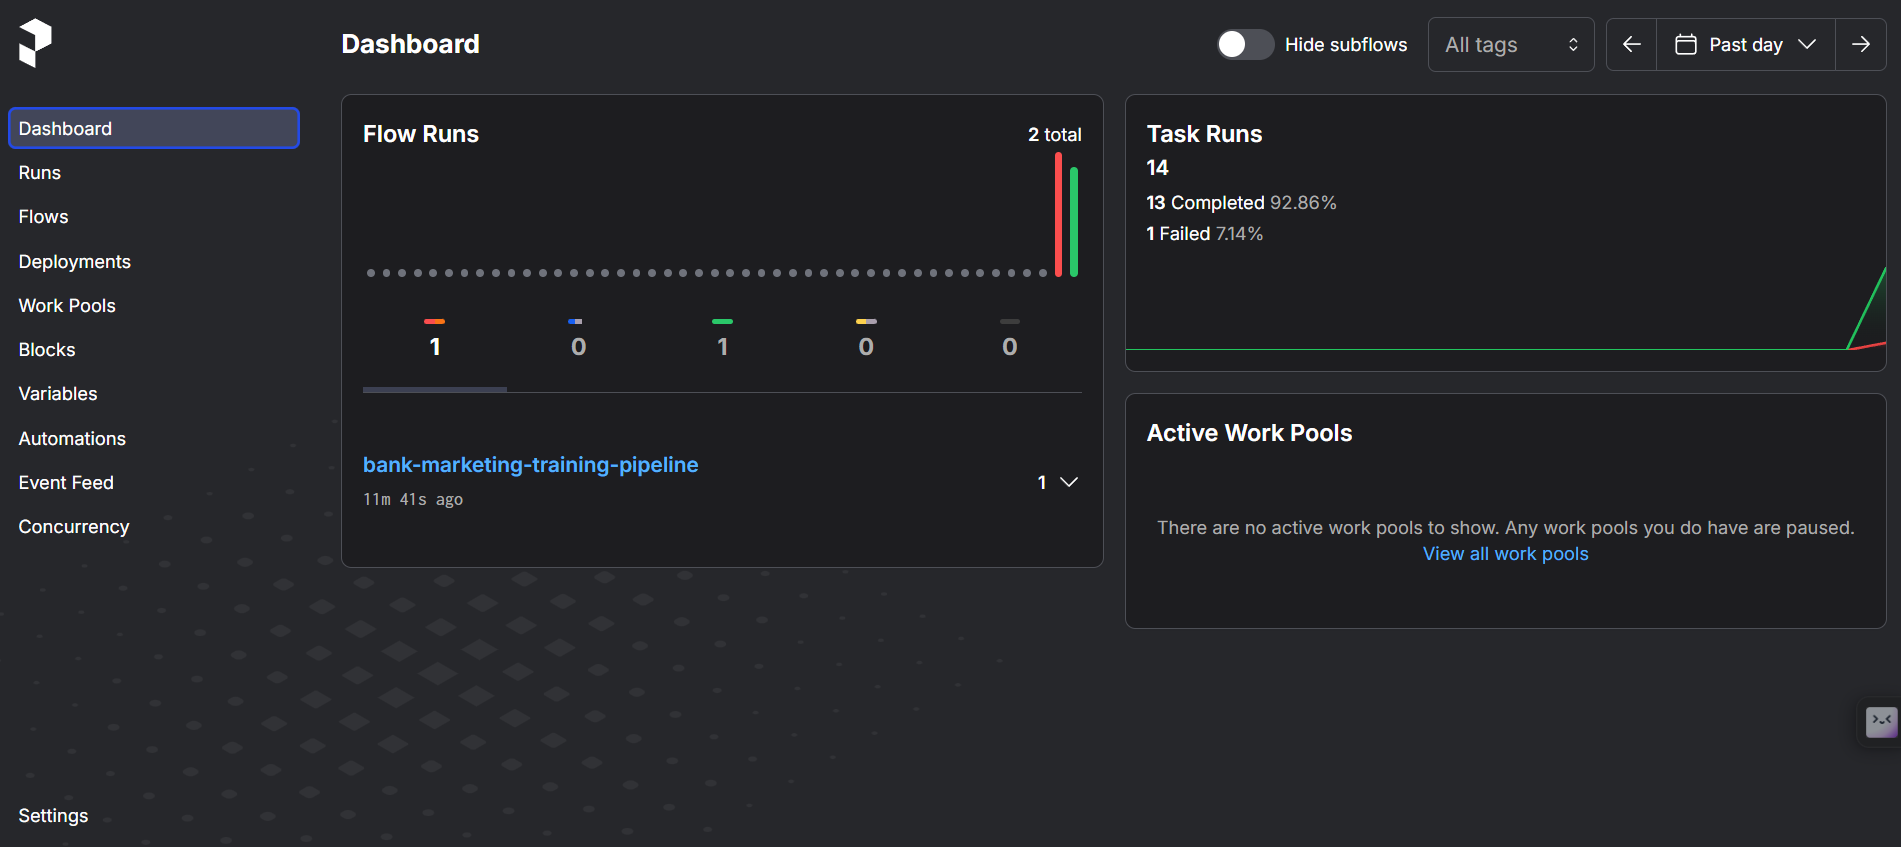


### 📌 Note — Prefect

Each `@task` automatically gets retry logic, logging, and dependency tracking from Prefect.
To move this from "runs on my machine" to "runs in production," the next steps are:

1. **`prefect deployment build`** this flow and register it with a Prefect work pool.
2. Add a **schedule** (e.g. weekly retraining as new campaign data accumulates).
3. Add a **model comparison gate** — only promote the new artifact if its F1/recall beats the
   currently deployed model on a held-out validation set (prevents silent regressions).
4. Connect **MLflow's model registry** as the source of truth for which model version
   `predict.py` should load, instead of a hardcoded local `.pkl` path.


## 24. Summary & Next Steps

This notebook took the project from raw data through to a tuned, threshold-optimized model,
packaged as a deployable artifact, with an initial MLOps in place.

**Completed:**
- ✅ Business problem framing and challenge definition
- ✅ Data inspection, cleaning, and three-level EDA (univariate / bivariate / multivariate)
- ✅ Pipeline-based feature scaling & encoding (shared with `train.py` / `predict.py`)
- ✅ Baseline model and 6-way multi-model comparison with overfit/underfit diagnostics
- ✅ Feature importance analysis and validated feature selection
- ✅ Class imbalance handling (class weighting vs. SMOTE)
- ✅ Hyperparameter tuning (LightGBM, Gradient Boosting)
- ✅ Threshold optimization and final model selection
- ✅ MLflow experiment tracking scaffold
- ✅ Prefect orchestration scaffold




# --- The End ---

**Open follow-ups before production deployment:**
- [ ] Update `predict.py` to use `preprocessing_pipeline` directly instead of its hand-coded
      encoding logic, so training and inference can never drift apart
- [ ] Add a model-comparison gate to the Prefect flow before promoting a new model
- [ ] Connect MLflow's model registry as the deployment source of truth
- [ ] Set up scheduled retraining and data/metric drift monitoring